# Importing Libraries and Defining Features

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
import scipy.stats
from linearmodels import PanelOLS


West_EU = ["Germany", "France", "Belgium", "Netherlands", "Luxembourg", "Austria", "Ireland"]
#West_EU = ["Germany", "France", "Belgium", "Netherlands", "Austria"]
East_EU = ["Bulgaria", "Hungary", "Czechia", "Poland", "Romania", "Slovakia"]
South_EU = ["Spain", "Slovenia", "Portugal", "Italy", "Croatia", "Greece"]
Nord_EU = ["Denmark", "Sweden", "Norway", "Finland", "Estonia", "Latvia", "Lithuania"]

ALL_COUNTRIES = West_EU + East_EU + South_EU + Nord_EU
#ALL_COUNTRIES = West_EU

#FEATURES = ["population_Mio", "gdp_per_capita_USD", "gdp_growth_rate_Percent", "hdd_DegreesC"]
FEATURES = ["gdp_growth_rate_Percent", "ln_hdd"]
FEATURES_ln = ["ln_pop", "ln_gdp_pc", "ln_hdd"]

TARGET = ["Total_Heat_TJ"]
TARGET_ln = ["ln_total_heat"]

# Data Preparation

## Preparing the data on share of technologies in Total Heat

In [2]:
nrg_d_hhq = pd.read_csv("Heat Pump/eurostat_nrg_d_hhq.csv")

# selecting only the wanted columns and renaming name
nrg_d_hhq = nrg_d_hhq[["nrg_bal", "Standard international energy product classification (SIEC)", "Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]
nrg_d_hhq= nrg_d_hhq.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "Energy_TJ",
    "Standard international energy product classification (SIEC)": "carrier"
})  

# sum of both space heating and water heating
nrg_d_hhq_heating = (
    nrg_d_hhq
    .groupby(["carrier", "country", "year"], as_index=False)["Energy_TJ"]
    .sum()
)

# Get the "Total" value for each country-year
totals = (
    nrg_d_hhq_heating[nrg_d_hhq_heating["carrier"] == "Total"]
    [["country", "year", "Energy_TJ"]]
    .rename(columns={"Energy_TJ": "Total_Energy_TJ"})
)

# Merge totals back to the main dataframe
nrg_d_hhq_heating = nrg_d_hhq_heating.merge(
    totals,
    on=["country", "year"],
    how="left"
)

# Compute share
nrg_d_hhq_heating["share_pu"] = (
    nrg_d_hhq_heating["Energy_TJ"] /
    nrg_d_hhq_heating["Total_Energy_TJ"]
)

#nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Total") & (nrg_d_hhq_heating.country=="Norway")]
nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.country=="France") & (nrg_d_hhq_heating.year==2024)]

,carrier,country,year,Energy_TJ,Total_Energy_TJ,share_pu
132,Ambient heat (heat pumps),France,2024,174289.222,1200657.665,0.145161
515,Gas oil and diesel oil,France,2024,106288.558,1200657.665,0.088525
898,Liquefied petroleum gases,France,2024,14465.872,1200657.665,0.012048
1281,Natural gas,France,2024,334150.240,1200657.665,0.278306
1664,Oil and petroleum products,France,2024,127649.748,1200657.665,0.106317
2047,Total,France,2024,1200657.665,1200657.665,1.000000


In [3]:
# saving the historical data of heat pump heat consumption to be used for historical electricity demand of them.
hist_hp_demand = nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Ambient heat (heat pumps)")]
hist_hp_demand.to_csv("Data - raw/prepared_data/hist_hp_heat_demand.csv")

In [4]:
# calculating average share of each carrier over 2010 to 2024
carrier_shares = nrg_d_hhq_heating.groupby(["country", "carrier"], as_index=False)["share_pu"].mean()
carrier_shares = carrier_shares[(carrier_shares.carrier!="Total")
                                & (carrier_shares.carrier!="Gas oil and diesel oil")
                                & (carrier_shares.carrier!="Liquefied petroleum gases")
                                ]
carrier_shares[carrier_shares.country=="Norway"]#.sum()

,country,carrier,share_pu
108,Norway,Ambient heat (heat pumps),0.123564
111,Norway,Natural gas,0.000788
112,Norway,Oil and petroleum products,0.021572


In [5]:
# caculating the maximum available share of Heat pumps per country
max_hp_share = carrier_shares.groupby(["country"])["share_pu"].sum()
max_hp_share

country
Austria        0.440016
Belgium        0.829804
Bulgaria       0.040029
Croatia        0.297118
Czechia        0.299351
Denmark        0.253124
Estonia        0.062948
Finland        0.160295
France         0.554859
Germany        0.713357
Greece         0.553204
Hungary        0.533975
Ireland        0.767110
Italy          0.683067
Latvia         0.104440
Lithuania      0.176030
Luxembourg     0.896873
Netherlands    0.879446
Norway         0.145923
Poland         0.212406
Portugal       0.495350
Romania        0.364833
Slovakia       0.548471
Slovenia       0.306233
Spain          0.637404
Sweden         0.032608
Name: share_pu, dtype: float64

In [6]:
# Handling the Assumptions of Norway and Finnland:
# The mean value of max available hp_share is less then the hp share in 2024. Therefore I will use the maximum value
# the hp_share had during the period of 2010 to 2024, plus the oil and gas share in the corresponding year
No_Fin_carrier_share = nrg_d_hhq_heating[
    (nrg_d_hhq_heating.country.isin(["Norway", "Finland"]))
    & (nrg_d_hhq_heating.carrier.isin(["Ambient heat (heat pumps)", "Natural gas", "Oil and petroleum products"]))
]

No_Fin_carrier_share = No_Fin_carrier_share[["carrier", "country", "year", "share_pu"]]

No_Fin_carrier_share = No_Fin_carrier_share.pivot(index=["year", "country"], columns="carrier", values="share_pu")


#max_hp_share.Norway = No_Fin_carrier_share.loc["Norway", 2023].sum()
max_hp_share.Norway = No_Fin_carrier_share.loc[2023, "Norway"].sum()
#max_hp_share.Finland = No_Fin_carrier_share.loc["Finland", 2023].sum()
max_hp_share.Finland = No_Fin_carrier_share.loc[2023, "Finland"].sum()

max_hp_share

country
Austria        0.440016
Belgium        0.829804
Bulgaria       0.040029
Croatia        0.297118
Czechia        0.299351
Denmark        0.253124
Estonia        0.062948
Finland        0.181114
France         0.554859
Germany        0.713357
Greece         0.553204
Hungary        0.533975
Ireland        0.767110
Italy          0.683067
Latvia         0.104440
Lithuania      0.176030
Luxembourg     0.896873
Netherlands    0.879446
Norway         0.170314
Poland         0.212406
Portugal       0.495350
Romania        0.364833
Slovakia       0.548471
Slovenia       0.306233
Spain          0.637404
Sweden         0.032608
Name: share_pu, dtype: float64

In [7]:
# seperating the target values of the model in heat_demand
heat_demand = nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Total")]
heat_demand = heat_demand[["country", "year", "Total_Energy_TJ"]]
heat_demand = heat_demand.rename(columns=
                                 {"Total_Energy_TJ": "Total_Heat_TJ"}
                                 )

# Norway value for 2024 is missing in csv file! so it is filled manually:
# Total, space heating: 131173.441 & water heating: 25183.669
new_row = pd.DataFrame({
    "country": ["Norway"],
    "year": [2024],
    "Total_Heat_TJ": [131173.441 + 25183.669]
})
heat_demand = pd.concat([heat_demand, new_row], ignore_index=True)


#heat_demand[(heat_demand.country=="Norway") & (heat_demand.year==2024)]

heat_demand

,country,year,Total_Heat_TJ
0,Austria,2010,251955.007
1,Austria,2011,232075.458
2,Austria,2012,237258.529
3,Austria,2013,247036.708
4,Austria,2014,221009.108
...,...,...,...
379,Sweden,2021,223346.499
380,Sweden,2022,208850.634
381,Sweden,2023,214675.124
382,Sweden,2024,210038.766


## Importing Panel Data (Features)

In [8]:
# importing panel data for population, gdp per capita and HDD
panel = pd.read_csv("Data - raw/prepared_data/panel_transformed.csv")
panel = panel[["year", "country"] + FEATURES]

In [9]:
# creating the training set of histroical data
hist = panel[panel.year <= 2024]
hist = hist.merge(heat_demand, on=["year", "country"], how="left")
hist = hist[hist.year >= 2010]

# missing values: filling forwardly
hist = hist.sort_values(["country", "year"])
hist["Total_Heat_TJ"] = (
    hist.groupby("country")["Total_Heat_TJ"]
    .ffill()
)

hist = hist.set_index(["country", "year"])

hist#[hist.country=="Lithuania"]

gdp_growth_rate_Percent    ln_hdd  Total_Heat_TJ
country year                                                  
Austria 2010                 1.710849  8.272347     251955.007
        2011                 3.000806  8.074398     232075.458
        2012                 0.592646  8.146563     237258.529
        2013                -0.369244  8.152612     247036.708
        2014                 0.762713  8.149901     221009.108
...                               ...       ...            ...
Sweden  2020                -1.924819  8.442473     209761.269
        2021                 5.632981  8.447937     223346.499
        2022                 1.194493  8.297176     208850.634
        2023                 0.093009  8.248988     214675.124
        2024                 0.431191  8.373914     210038.766

[390 rows x 3 columns]

In [10]:
# Replacing values of Zero with NaN and then fill them backward for each country!
# replace 0 with NaN
hist["Total_Heat_TJ"] = (
    hist["Total_Heat_TJ"]
    .replace(0, np.nan)
)

# fill using next available year within each country
hist["Total_Heat_TJ"] = (
    hist.groupby(level="country")["Total_Heat_TJ"]
    .bfill()
)

hist["ln_total_heat"] = np.log1p(hist['Total_Heat_TJ'])

In [11]:
# preparing the projection input data
proj = panel[panel.year > 2024]

proj = proj.set_index(["country", "year"])

proj

,,gdp_growth_rate_Percent,ln_hdd
country,year,,
Austria,2025,-0.036296,8.125675
Belgium,2025,1.156512,7.648291
Bulgaria,2025,2.927476,7.767877
Croatia,2025,3.896182,7.495500
Czechia,2025,2.120203,7.954813
...,...,...,...
Romania,2060,1.007720,7.841816
Slovakia,2060,0.888031,7.957286
Slovenia,2060,1.617258,7.715048


## Plotting Function

In [12]:
def plot_heat_demand(
    hist,
    proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # or "ML_predictions"
    proj_pred_col="Total_Heat_TJ",          # or "Total_Heat_TJ_PanelOLS" / "Total_Heat_TJ_ML"
    countries_list=None,
    title="Heat Demand: Actuals, Model Fit & Projection",
    test_split_year=2020,
    NCOLS = 5
):
    """
    Grid plot of heat demand for every country (max 3 columns).

    Parameters
    ----------
    hist            : DataFrame with (country, year) MultiIndex
    proj            : DataFrame with (country, year) MultiIndex
    hist_actual_col : column in hist plotted as solid blue (actuals)
    hist_pred_col   : column in hist plotted as dotted orange (model predictions)
    proj_pred_col   : column in proj plotted as dashed green (projection)
    countries_list  : countries to include (default: all in hist index)
    year            : draw a vertical red dotted line at this year (default: 2020)
    """
    if countries_list is None:
        countries_list = sorted(hist.index.get_level_values("country").unique().tolist())

    n     = len(countries_list)
    ncols = NCOLS
    nrows = math.ceil(n / ncols)

    '''    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(21, nrows * 3),
        constrained_layout=True,
    )'''

    fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 5.5, nrows * 3.5))
    axes_flat = axes.flatten()

    for i, country in enumerate(countries_list):
        ax = axes_flat[i]

        # ── Actual historical values (solid blue) ───────────────────────────
        try:
            actual = hist[hist_actual_col].xs(country, level="country")
            ax.plot(actual.index, actual.values,
                    "-", color="steelblue", lw=1.5, label="Actual")
        except KeyError:
            pass

        # ── Historical model predictions (dotted orange) ────────────────────
        if hist_pred_col in hist.columns:
            try:
                pred = hist[hist_pred_col].xs(country, level="country")
                ax.plot(pred.index, pred.values,
                        ":", color="darkorange", lw=1.8, label=f"Model ({hist_pred_col})")
            except KeyError:
                pass

        # ── Future projection (dashed green) ────────────────────────────────
        if proj_pred_col in proj.columns:
            try:
                fut = proj[proj_pred_col].xs(country, level="country")
                ax.plot(fut.index, fut.values,
                        "--", color="seagreen", lw=1.5, label=f"Projection ({proj_pred_col})")
            except KeyError:
                pass

        # ── Train/test split line (red dotted vertical) ──────────────────────
        #ax.axvline(x=test_split_year, color="red", linestyle=":", lw=1.5, label=f"Test split ({test_split_year})", alpha=0.3)
        if test_split_year is not None:
            ax.axvline(x=test_split_year, color="red", lw=1.0, ls="--", alpha=0.3,
                        label=f"Train/Test split ({test_split_year})" if i == 0 else "_nolegend_")

        ax.set_title(country, fontsize=9, fontweight="bold")
        ax.set_ylabel("Heat Consumption (TJ)", fontsize=7)
        ax.tick_params(axis="both", labelsize=7)
        ax.set_ylim(bottom=0)

    # Hide any unused subplot slots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Shared legend above the grid
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=10,
               frameon=True, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.04)

    #plt.savefig("heat_demand_forecast.png", dpi=120, bbox_inches="tight")
    #plt.show()
    return None#fig

# ── Call with PanelOLS predictions ───────────────────────────────────────────
"""plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="Total_Heat_TJ",          # change to "Total_Heat_TJ_ML" when ready
)"""

# ── Example: swap in ML predictions once available ───────────────────────────
# plot_heat_demand(hist, proj, hist_pred_col="ML_predictions", proj_pred_col="Total_Heat_TJ_ML")

'plot_heat_demand(\n    hist=hist,\n    proj=proj,\n    hist_actual_col="Total_Heat_TJ",\n    hist_pred_col="panel_predictions",      # column added in the prediction cell above\n    proj_pred_col="Total_Heat_TJ",          # change to "Total_Heat_TJ_ML" when ready\n)'

## Usefull Area BSO

EU Building Stock Observatory https://energy.ec.europa.eu/topics/energy-efficiency/energy-performance-buildings/eu-building-stock-observatory_en

containing the data of how much usefull floor area is available in each country, and also the share of buildings for each construction year. 
BSO was last updated in May 2026.
The state of data is for year 2020!!

it does not contain the data of Norway

In [13]:
bso = pd.read_excel("Heat Pump/heat_pumps.xlsx", sheet_name="heat_spec_distribution")
bso = bso[:27] # keeping only relevant data
bso = bso[bso.Country.isin(ALL_COUNTRIES)]
bso = bso.set_index("Country")

bso

,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Austria,480479871,0.226669,0.265689,0.153497,0.123125,0.141204,0.069105,0.02071
Belgium,693785280,0.411845,0.217941,0.121747,0.084841,0.064261,0.062943,0.036422
Bulgaria,321201659,0.20838,0.226748,0.145953,0.137376,0.107167,0.111183,0.063192
Croatia,182977135,0.129597,0.171136,0.183956,0.140586,0.128498,0.157216,0.089011
Czechia,387472106,0.178462,0.208683,0.203641,0.127887,0.087488,0.1155,0.078338
Denmark,341768565,0.206363,0.182657,0.200548,0.101004,0.100508,0.106585,0.102335
Estonia,27472583,0.330614,0.211147,0.085553,0.076144,0.117936,0.115091,0.063515
Finland,406877934,0.146812,0.234661,0.147952,0.186731,0.123418,0.133904,0.026521
France,3087013302,0.182696,0.141576,0.155983,0.149489,0.098669,0.147054,0.124533


In [14]:
# Importing the Data for Norway in the format Above from Excel Caculations from SSB.no website!
norway_floor = pd.read_excel("Heat Pump/Norway_building_floor_data.xlsx", sheet_name="Norway_floor_data_2020", index_col=0)
norway_floor

,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Norway,513839335,0.108895,0.154981,0.099113,0.092145,0.051145,0.241651,0.252069


In [15]:
bso = pd.concat([bso, norway_floor])
bso

,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Austria,480479871,0.226669,0.265689,0.153497,0.123125,0.141204,0.069105,0.02071
Belgium,693785280,0.411845,0.217941,0.121747,0.084841,0.064261,0.062943,0.036422
Bulgaria,321201659,0.20838,0.226748,0.145953,0.137376,0.107167,0.111183,0.063192
Croatia,182977135,0.129597,0.171136,0.183956,0.140586,0.128498,0.157216,0.089011
Czechia,387472106,0.178462,0.208683,0.203641,0.127887,0.087488,0.1155,0.078338
Denmark,341768565,0.206363,0.182657,0.200548,0.101004,0.100508,0.106585,0.102335
Estonia,27472583,0.330614,0.211147,0.085553,0.076144,0.117936,0.115091,0.063515
Finland,406877934,0.146812,0.234661,0.147952,0.186731,0.123418,0.133904,0.026521
France,3087013302,0.182696,0.141576,0.155983,0.149489,0.098669,0.147054,0.124533


In [16]:
# floor area and thermal index now come from floor_area_panel.ipynb instead of being
# calculated here - it reconstructs 2010-2024 from Eurostat building permits and
# projects 2025-2060 with demand-driven construction, demolition and renovation rates.

FLOOR_PANEL_PATH        = "Data - raw/prepared_data/floor_panel_2010_2060.csv"
FLOOR_BASELINE_SCENARIO = "KKO"     # scenario used for the single-pathway `proj`
FLOOR_COLS = ["ln_total_floor", "ln_thermal_index", "total_floor_m2", "thermal_index"]

floor_all = pd.read_csv(FLOOR_PANEL_PATH)
floor_all = floor_all[floor_all.country.isin(ALL_COUNTRIES)]

# history 2010–2024: observation-based, identical across scenarios
floor_hist_panel = (floor_all[floor_all.scenario == "HIST"]
                    .set_index(["country", "year"])[FLOOR_COLS])

# projection 2025–2060: one row per country × year × scenario
floor_proj_panel = floor_all[floor_all.scenario != "HIST"][
    ["country", "year", "scenario"] + FLOOR_COLS]

# baseline pathway for the non-scenario `proj` further down
floor_proj_baseline = (floor_proj_panel[floor_proj_panel.scenario == FLOOR_BASELINE_SCENARIO]
                       .drop(columns="scenario")
                       .set_index(["country", "year"]))

floor_panel = pd.concat([floor_hist_panel, floor_proj_baseline])

print(f"floor panel: {len(floor_hist_panel)} historical + "
      f"{len(floor_proj_panel)} projected rows "
      f"({floor_proj_panel.scenario.nunique()} scenarios)")
floor_panel.head()

floor panel: 390 historical + 1248 projected rows (4 scenarios)


ln_total_floor  ln_thermal_index  total_floor_m2  thermal_index
country year                                                                 
Austria 2010       19.984013          5.233116    4.774705e+08     186.375709
        2011       19.984307          5.231496    4.776108e+08     186.072483
        2012       19.984831          5.229711    4.778613e+08     185.738758
        2013       19.985131          5.228090    4.780048e+08     185.436328
        2014       19.985605          5.226345    4.782314e+08     185.111245

In [17]:
floor_panel

ln_total_floor  ln_thermal_index  total_floor_m2  thermal_index
country year                                                                 
Austria 2010       19.984013          5.233116    4.774705e+08     186.375709
        2011       19.984307          5.231496    4.776108e+08     186.072483
        2012       19.984831          5.229711    4.778613e+08     185.738758
        2013       19.985131          5.228090    4.780048e+08     185.436328
        2014       19.985605          5.226345    4.782314e+08     185.111245
...                      ...               ...             ...            ...
Sweden  2040       20.169515          4.851308    5.747899e+08     126.907634
        2045       20.206233          4.809815    5.962872e+08     121.708887
        2050       20.238535          4.772037    6.158630e+08     117.159686
        2055       20.265708          4.738207    6.328274e+08     113.229173
        2060       20.290004          4.706188    6.483906e+08     109.629646

[702 rows x 4 columns]

In [18]:
BUILDING_FEATURES = ["ln_total_floor", "ln_thermal_index"]
FEATURES = FEATURES + BUILDING_FEATURES

hist = hist.join(floor_panel)
proj = proj.join(floor_panel)

assert hist[BUILDING_FEATURES].notna().all().all(), "missing floor data in hist"
assert proj[BUILDING_FEATURES].notna().all().all(), "missing floor data in proj"
hist.head()

gdp_growth_rate_Percent    ln_hdd  Total_Heat_TJ  ln_total_heat  \
country year                                                                    
Austria 2010                 1.710849  8.272347     251955.007      12.437010   
        2011                 3.000806  8.074398     232075.458      12.354822   
        2012                 0.592646  8.146563     237258.529      12.376910   
        2013                -0.369244  8.152612     247036.708      12.417296   
        2014                 0.762713  8.149901     221009.108      12.305964   

              ln_total_floor  ln_thermal_index  total_floor_m2  thermal_index  
country year                                                                   
Austria 2010       19.984013          5.233116    4.774705e+08     186.375709  
        2011       19.984307          5.231496    4.776108e+08     186.072483  
        2012       19.984831          5.229711    4.778613e+08     185.738758  
        2013       19.985131          5.228090    4.780048e+08     185.436328  
        2014       19.985605          5.226345    4.782314e+08     185.111245

# Model

### define a function to predict using entity effects and considering the "logaritmic term"

In [19]:
def predict_logaritmic(model, df, X, LN=True):
    # it gets the model (PanelOLS) and a dataFrame containing features to predict the target variable in a new column "panel_predictions"
    
    # saving the entity effects per country
    entity_effects = model.estimated_effects.groupby('country')["estimated_effects"].mean()

    # predicting the ln(Target)
    df["panel_predictions"] = model.predict(X)["predictions"]

    # adding the entity effect to ln(Target)
    df["panel_predictions"] = (
    df["panel_predictions"]
        + df.index.get_level_values("country").map(entity_effects)
    )

    # # calculate the exponential of it, because the model is on "ln"
    if LN:
        df["panel_predictions"] = np.expm1(df["panel_predictions"])

    return df

## Panel OLS Model

### Training with Data until 2020 and Testing for 2020 to 2024

In [20]:
X = hist[FEATURES]
Y = hist[TARGET_ln]

TRAIN_TEST_YEAR = 2022
X_train = X[X.index.get_level_values('year') <= TRAIN_TEST_YEAR]
Y_train = Y[Y.index.get_level_values('year') <= TRAIN_TEST_YEAR]

X_test = X[X.index.get_level_values('year') >= TRAIN_TEST_YEAR]
Y_test = Y[Y.index.get_level_values('year') >= TRAIN_TEST_YEAR]


m_panelOLS = PanelOLS(Y_train, X_train,
                      entity_effects=True,
                      ).fit(
                          #cov_type="clustered",
                          #cluster_entity=True,
                      )
m_panelOLS

Dep. Variable:,ln_total_heat,R-squared:,0.0416
Estimator:,PanelOLS,R-squared (Between):,-0.0223
No. Observations:,338,R-squared (Within):,0.0416
Date:,"Wed, Sep 02 2026",R-squared (Overall):,-0.0223
Time:,17:49:51,Log-likelihood,401.34
Cov. Estimator:,Unadjusted,,
,,F-statistic:,3.3395
Entities:,26,P-value,0.0107
Avg Obs:,13.000,Distribution:,"F(4,308)"
Min Obs:,13.000,,
Max Obs:,13.000,F-statistic (robust):,3.3395


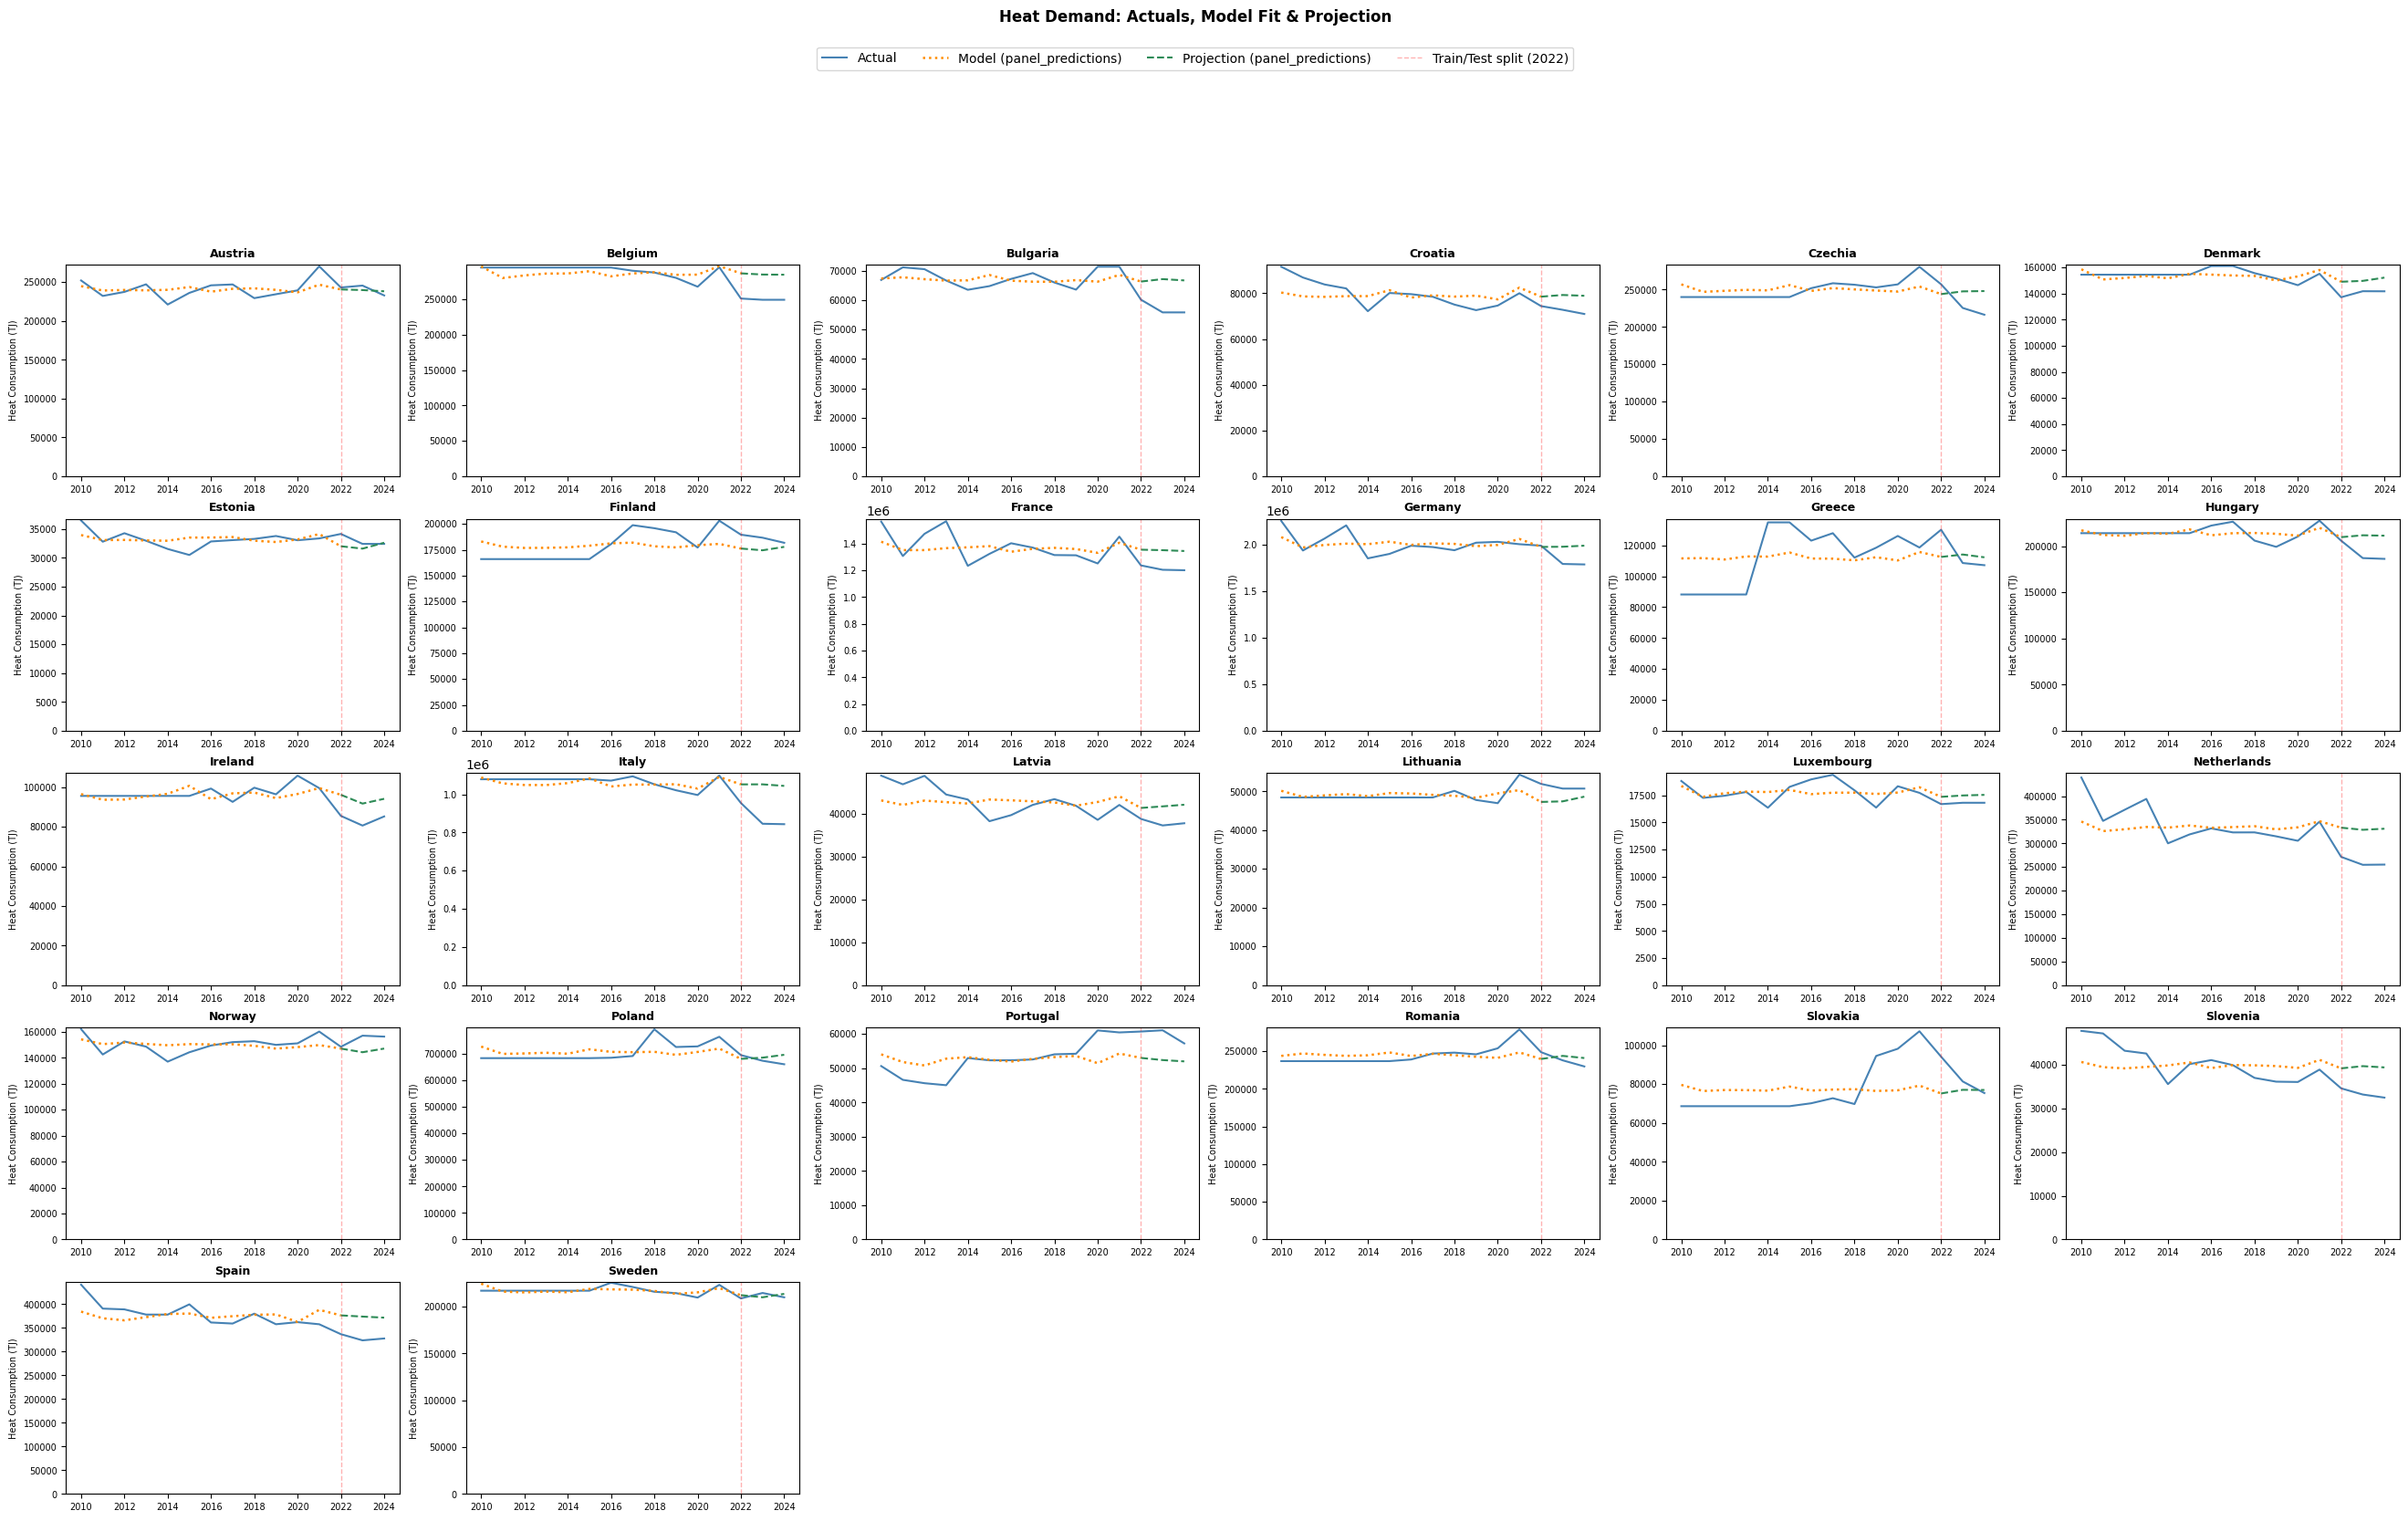

In [21]:
# predictions for historical data (training set)
hist = predict_logaritmic(m_panelOLS, hist, X_train, LN=True)

# Raw model projection for test set
#proj = predict_logaritmic(m_panelOLS, proj, X_proj, LN=True)
X_test = predict_logaritmic(m_panelOLS, X_test, X_test, LN=True)

# plotting the results of PanelOLS model
plot_heat_demand(
    hist=hist,
    proj=X_test,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="panel_predictions",          # change to "Total_Heat_TJ_ML" when ready
    test_split_year=TRAIN_TEST_YEAR,
    NCOLS=6
)

The Model uses ln of input variables (population, gdp_per_capita, HDD) to calculate ln_total_heat

### Training on all historical data

In [22]:
X = hist[FEATURES]
Y = hist[TARGET_ln]

#X = sm.add_constant(X)

m_panelOLS = PanelOLS(Y, X,
                      entity_effects=True,
                      ).fit(
                        #cov_type="clustered",
                        #cluster_entity=True,
                      )
m_panelOLS

Dep. Variable:,ln_total_heat,R-squared:,0.1007
Estimator:,PanelOLS,R-squared (Between):,-13.042
No. Observations:,390,R-squared (Within):,0.1007
Date:,"Wed, Sep 02 2026",R-squared (Overall):,-13.041
Time:,17:49:52,Log-likelihood,444.77
Cov. Estimator:,Unadjusted,,
,,F-statistic:,10.075
Entities:,26,P-value,0.0000
Avg Obs:,15.000,Distribution:,"F(4,360)"
Min Obs:,15.000,,
Max Obs:,15.000,F-statistic (robust):,10.075


In [23]:
# predictions for historical data
hist = predict_logaritmic(m_panelOLS, hist, X, LN=True)

# Raw model projection 2025–2060
X_proj = proj[FEATURES]
#X_proj = sm.add_constant(X_proj)
proj = predict_logaritmic(m_panelOLS, proj, X_proj, LN=True)

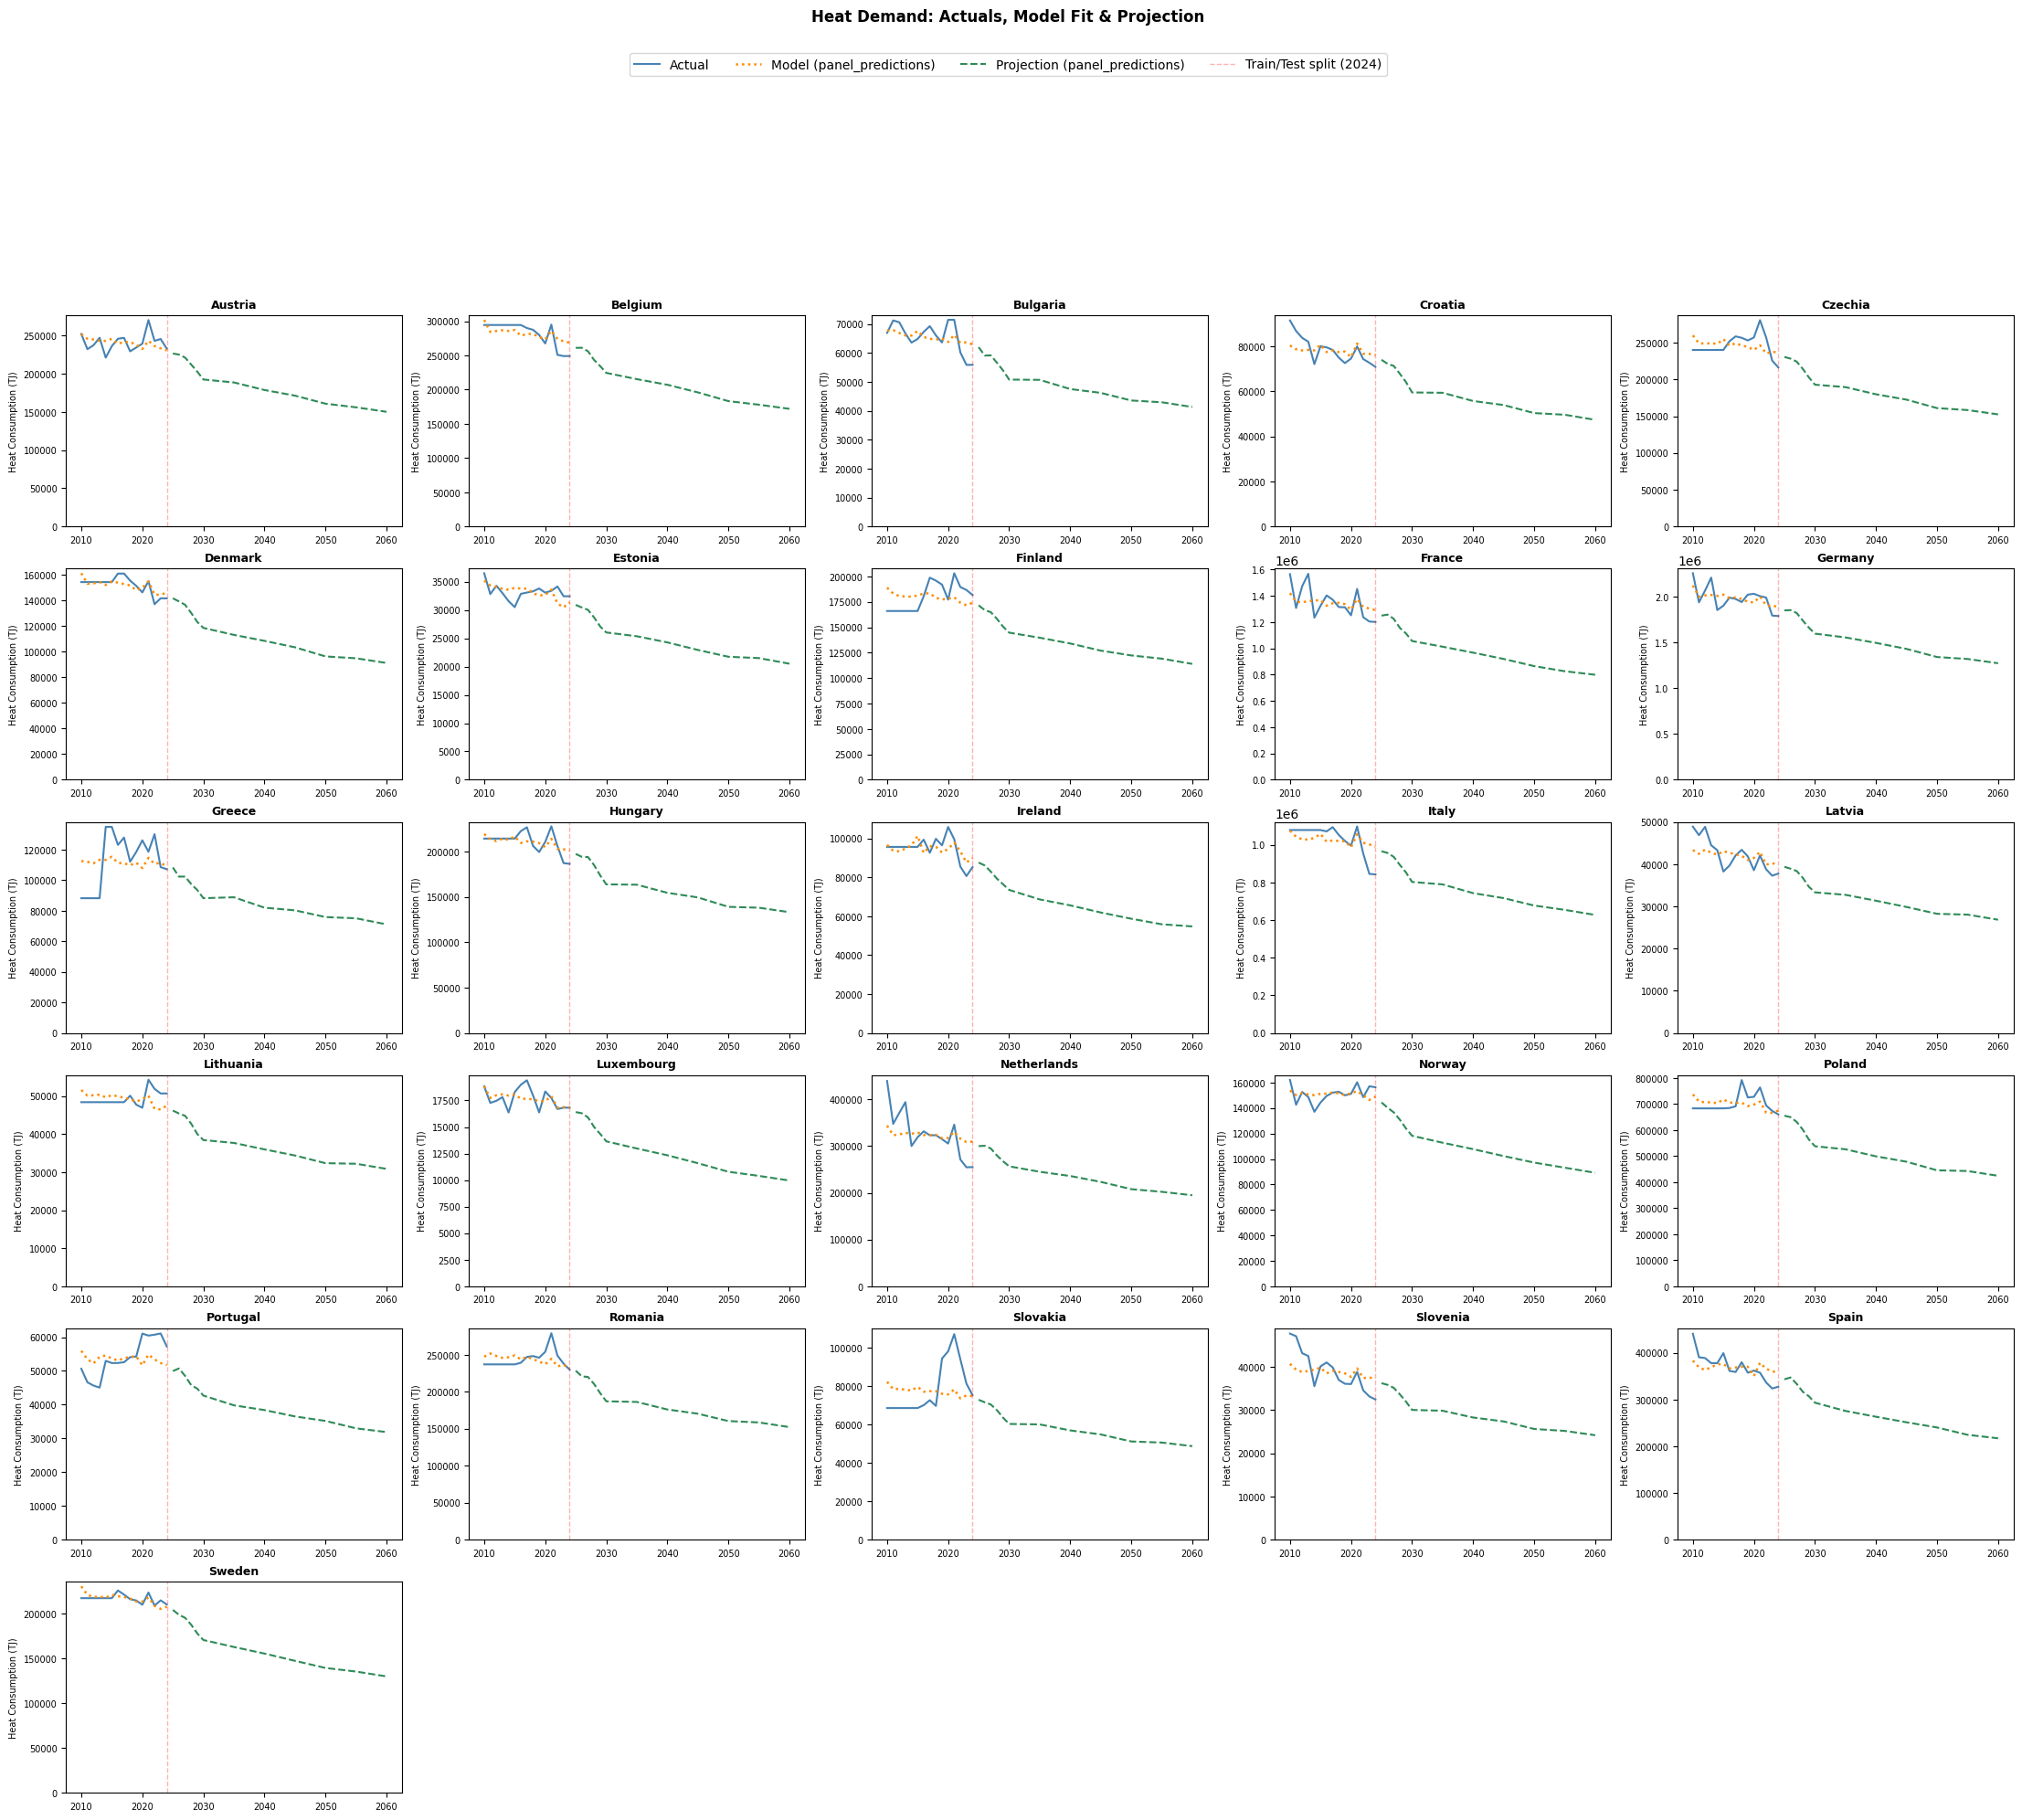

In [24]:
# plotting the results of PanelOLS model
plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="panel_predictions",          # change to "Total_Heat_TJ_ML" when ready
    test_split_year=hist.index.get_level_values('year').max()
)

## Scenario-Based HDD/CDD Total-Heat Projection (SSP1/SSP2/SSP3/SSP5)

Everything above trains the model once and produces one projection (`proj`) from the single
RCP4.5 HDD pathway in `panel_transformed.csv`.

Set `USE_HDD_CDD_SCENARIOS = True` to build four total-heat-demand projections instead, one per
climate scenario, using the scenario-specific HDD/CDD from
`Data - raw/chdd_data/chdd_calculation_scenarios.ipynb`. Each climate scenario pairs with the
matching heat-pump-adoption scenario from the `SCENARIOS` dict used below for the share
projection:

| Climate scenario | HP-adoption scenario |
|-------------------|----------------------|
| SSP1 (SP126)       | KKO                  |
| SSP2 (SP245)       | KVE                  |
| SSP5 (SP585)       | VWE                  |
| SSP3 (SP370)       | VNI                  |

`m_panelOLS` (already trained above) is reused as-is - only the HDD input changes per scenario,
population/GDP growth/floor area/thermal index stay the same across scenarios. If
`USE_HDD_CDD_SCENARIOS = False`, this whole section is a no-op and the Heat Pump Electricity
Demand section below just uses the single RCP4.5 pathway like before.

In [25]:
# four climate-scenario HDD paths (SSP1/SSP2/SSP3/SSP5) instead of the single RCP4.5
# pathway above, plus the climate-scenario -> HP-adoption mapping. Tunable via
# scenario_config.py.
from scenario_config import USE_HDD_CDD_SCENARIOS, CLIMATE_SCENARIO_MAP

"""if USE_HDD_CDD_SCENARIOS:
    hdd_cdd_scenarios = pd.read_csv("Data - raw/chdd_data/output_csv/hdd_cdd_scenarios_2025_2060.csv")
    hdd_cdd_scenarios = hdd_cdd_scenarios[["scenario", "country", "year", "hdd_annual", "cdd_annual"]]
    hdd_cdd_scenarios = hdd_cdd_scenarios.rename(columns={"hdd_annual": "hdd_DegreesC", "cdd_annual": "cdd_DegreesC"})
    hdd_cdd_scenarios = hdd_cdd_scenarios[hdd_cdd_scenarios["country"].isin(ALL_COUNTRIES)]

    # scenario-independent projection features (gdp growth, floor area, thermal index, ...)
    proj_base = proj.drop(columns=["hdd_DegreesC", "cdd_DegreesC", "ln_hdd"], errors="ignore").reset_index()

    proj_scenarios = hdd_cdd_scenarios.merge(proj_base, on=["country", "year"], how="left")
    proj_scenarios["ln_hdd"] = np.log1p(proj_scenarios["hdd_DegreesC"])
    proj_scenarios = proj_scenarios.set_index(["country", "year"])

    # predict Total_Heat_TJ (ln model) for every scenario using the model trained above
    X_proj_scenarios = proj_scenarios[FEATURES]
    proj_scenarios = predict_logaritmic(m_panelOLS, proj_scenarios, X_proj_scenarios, LN=True)"""

if USE_HDD_CDD_SCENARIOS:
    hdd_cdd_scenarios = pd.read_csv("Data - raw/chdd_data/output_csv/hdd_cdd_scenarios_2025_2060.csv")
    hdd_cdd_scenarios = hdd_cdd_scenarios[["scenario", "country", "year", "hdd_annual", "cdd_annual"]]
    hdd_cdd_scenarios = hdd_cdd_scenarios.rename(columns={"hdd_annual": "hdd_DegreesC",
                                                          "cdd_annual": "cdd_DegreesC"})
    hdd_cdd_scenarios = hdd_cdd_scenarios[hdd_cdd_scenarios["country"].isin(ALL_COUNTRIES)]

    # scenario-independent projection features (gdp growth, population, ...)
    # NOTE: the floor columns are dropped here and re-merged per scenario below
    proj_base = proj.drop(columns=["hdd_DegreesC", "cdd_DegreesC", "ln_hdd"] + FLOOR_COLS,
                          errors="ignore").reset_index()

    proj_scenarios = hdd_cdd_scenarios.merge(proj_base, on=["country", "year"], how="left")
    proj_scenarios = proj_scenarios.merge(floor_proj_panel,
                                          on=["country", "year", "scenario"], how="left")
    proj_scenarios["ln_hdd"] = np.log1p(proj_scenarios["hdd_DegreesC"])
    proj_scenarios = proj_scenarios.set_index(["country", "year"])

    assert proj_scenarios[FEATURES].notna().all().all(), "missing features in proj_scenarios"

    # predict Total_Heat_TJ (ln model) for every scenario using the model trained above
    X_proj_scenarios = proj_scenarios[FEATURES]
    proj_scenarios = predict_logaritmic(m_panelOLS, proj_scenarios, X_proj_scenarios, LN=True)

proj_scenarios[proj_scenarios.index.get_level_values("country") == "Germany"] if USE_HDD_CDD_SCENARIOS else None

proj_scenarios[proj_scenarios.index.get_level_values("country") == "Germany"] if USE_HDD_CDD_SCENARIOS else None


scenario  hdd_DegreesC  cdd_DegreesC  gdp_growth_rate_Percent  \
country year                                                                 
Germany 2025      KKO   2439.863882     52.544875                 0.402901   
        2026      KKO   2431.036785     47.962508                 1.189015   
        2027      KKO   2407.282421     38.703778                 0.840903   
        2028      KKO   2535.384527     56.406822                 0.759025   
        2029      KKO   2362.028508     48.035075                 0.712156   
        2030      KKO   2759.779750     13.650640                 0.737105   
        2035      KKO   2481.341807     26.230867                 1.163004   
        2040      KKO   2484.236468     77.942948                 1.459517   
        2045      KKO   2707.724990     85.253497                 1.305019   
        2050      KKO   2354.191672     32.261403                 1.178026   
        2055      KKO   1986.220307     57.557817                 1.056781   
        2060      KKO   2187.777673     44.114780                 1.223914   
        2025      KVE   2130.400980    118.341572                 0.402901   
        2026      KVE   2303.489402     90.215913                 1.189015   
        2027      KVE   2411.036293     76.350035                 0.840903   
        2028      KVE   2445.572258     96.359043                 0.759025   
        2029      KVE   2185.413758     97.066778                 0.712156   
        2030      KVE   2553.100190     40.727137                 0.737105   
        2035      KVE   2364.869045     29.003630                 1.163004   
        2040      KVE   2430.402038    138.849018                 1.459517   
        2045      KVE   2397.532440     35.419405                 1.305019   
        2050      KVE   2243.263507     66.148197                 1.178026   
        2055      KVE   2092.056704     66.633030                 1.056781   
        2060      KVE   2356.840931     70.449510                 1.223914   
        2025      VNI   2724.870011     79.326290                 0.402901   
        2026      VNI   2215.402640     60.768990                 1.189015   
        2027      VNI   2426.186334     47.113473                 0.840903   
        2028      VNI   2646.151619     11.529065                 0.759025   
        2029      VNI   2495.052386     36.187460                 0.712156   
        2030      VNI   2226.554240    112.215210                 0.737105   
        2035      VNI   2366.087068     25.031815                 1.163004   
        2040      VNI   2466.245874     31.854077                 1.459517   
        2045      VNI   2164.930315     57.507577                 1.305019   
        2050      VNI   2118.240383    165.768998                 1.178026   
        2055      VNI   2025.362355     87.280378                 1.056781   
        2060      VNI   2392.414483     29.513670                 1.223914   
        2025      VWE   2578.967876     16.469417                 0.402901   
        2026      VWE   2303.951916     50.752090                 1.189015   
        2027      VWE   2185.814800     48.222702                 0.840903   
        2028      VWE   2550.685523     36.029990                 0.759025   
        2029      VWE   2407.700115     77.468388                 0.712156   
        2030      VWE   2238.873610     37.202728                 0.737105   
        2035      VWE   2323.076088     63.964928                 1.163004   
        2040      VWE   2274.746214     74.211765                 1.459517   
        2045      VWE   2522.179680    103.447648                 1.305019   
        2050      VWE   2379.710918     59.353740                 1.178026   
        2055      VWE   2509.420441     37.010165                 1.056781   
        2060      VWE   2237.673537    100.062405                 1.223914   

              panel_predictions  ln_total_floor  ln_thermal_index  \
country year                               

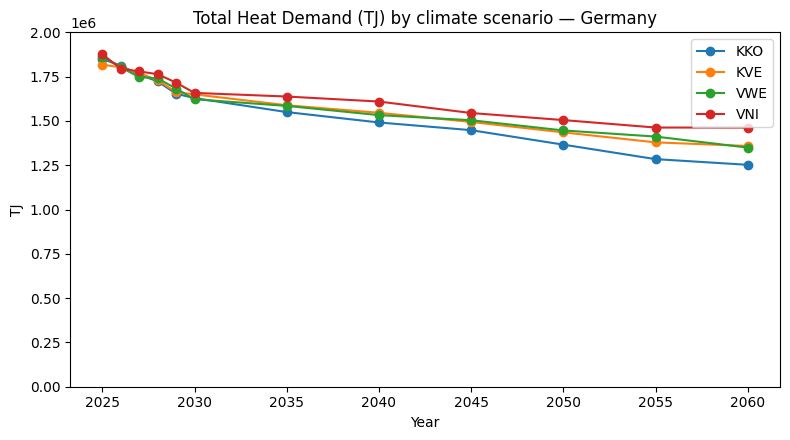

In [26]:
# Sanity-check: total heat demand (Total_Heat_TJ) predicted per climate scenario
if USE_HDD_CDD_SCENARIOS:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    d_all = proj_scenarios.reset_index()
    for scenario in CLIMATE_SCENARIO_MAP:
        d = d_all[(d_all["country"] == "Germany") & (d_all["scenario"] == scenario)].sort_values("year")
        ax.plot(d["year"], d["panel_predictions"], marker="o", label=scenario)
    ax.set_title("Total Heat Demand (TJ) by climate scenario — Germany")
    ax.set_xlabel("Year")
    ax.set_ylabel("TJ")
    ax.set_ylim(0,2e6)
    ax.legend()
    plt.tight_layout()
    plt.show()


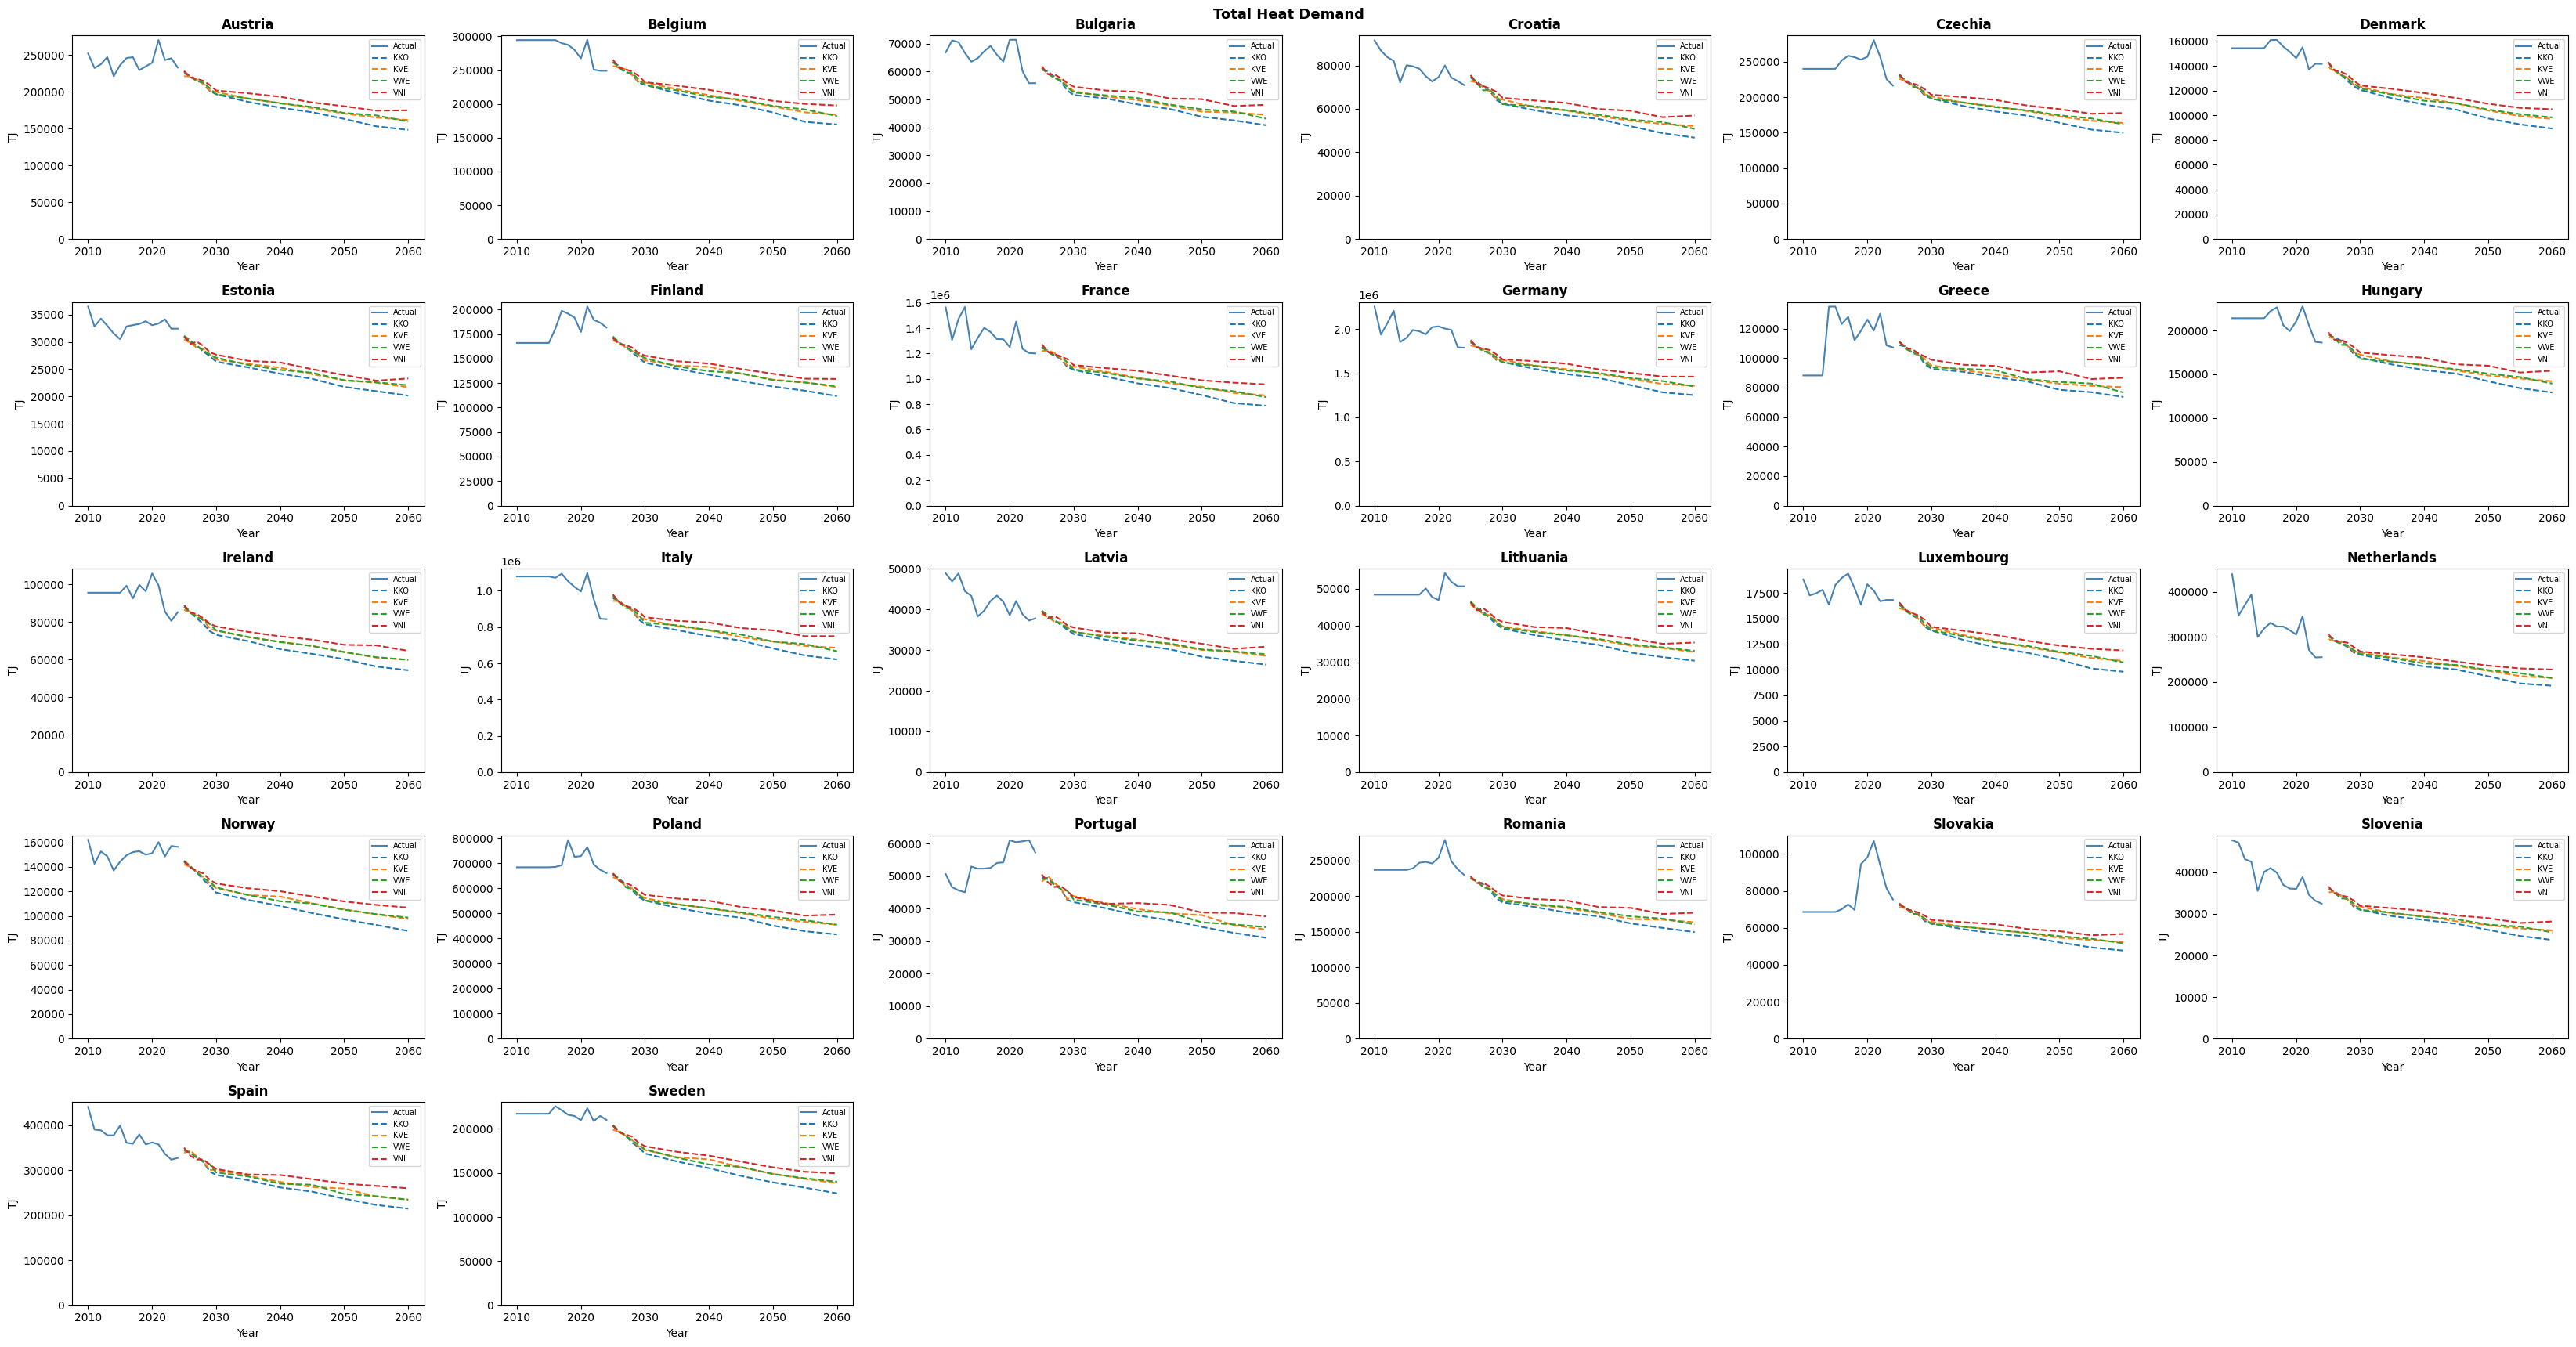

In [27]:
# Plot buildings-rest electricity demand per country, one colored line per climate scenario
# (mirrors the scenario-colored grid plot in heat_pump_ols.ipynb)
if USE_HDD_CDD_SCENARIOS:
    import math

    CHECK_COUNTRIES = sorted(ALL_COUNTRIES)
    n_cols = 6
    n_rows = math.ceil(len(CHECK_COUNTRIES) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5.5, n_rows * 3.5))
    axes = axes.flatten()

    hist_reset = hist.reset_index()
    proj_scenarios_reset = proj_scenarios.reset_index()

    for ax, country in zip(axes, CHECK_COUNTRIES):
        actual = hist_reset[hist_reset["country"] == country]
        ax.plot(actual["year"], actual["Total_Heat_TJ"],
                "-", color="steelblue", lw=1.5, label="Actual")

        for scenario in CLIMATE_SCENARIO_MAP:
            d = proj_scenarios_reset[
                (proj_scenarios_reset["country"] == country) &
                (proj_scenarios_reset["scenario"] == scenario)
            ]
            ax.plot(d["year"], d["panel_predictions"], "--", label=scenario)

        ax.set_title(country, fontweight="bold")
        ax.set_xlabel("Year")
        ax.set_ylabel("TJ")
        ax.legend(fontsize=7)
        ax.set_ylim(bottom=0)

    for ax in axes[len(CHECK_COUNTRIES):]:
        ax.set_visible(False)

    plt.suptitle("Total Heat Demand",
                  fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Heat Pump Share Projection

In [28]:
hp_shares_hist = nrg_d_hhq_heating[nrg_d_hhq_heating.carrier == "Ambient heat (heat pumps)"]
hp_shares_hist = hp_shares_hist[["country", "year", "share_pu"]]

# filling the last value for Bulgaria
hp_shares_hist.loc[
    (hp_shares_hist["country"] == "Bulgaria") & 
    (hp_shares_hist["year"] == 2024), 
    "share_pu"
] = 0

hp_shares_hist[hp_shares_hist.country == "Lithuania"]

,country,year,share_pu
223,Lithuania,2010,NaN
224,Lithuania,2011,NaN
225,Lithuania,2012,NaN
226,Lithuania,2013,NaN
227,Lithuania,2014,NaN
228,Lithuania,2015,NaN
229,Lithuania,2016,NaN
230,Lithuania,2017,0.000000
231,Lithuania,2018,0.018591
232,Lithuania,2019,0.020451


In [29]:
# year when max share is reached, and what fraction of max is the target
# tunable via scenario_config.py (stored there as HP_SCENARIOS)
from scenario_config import HP_SCENARIOS as SCENARIOS

In [30]:
# Building share projections per scenario --> hp_shares_proj
# The development of heat pump shares follows a logistic S-curve (technology diffusion)
PROJ_YEARS = list(range(2025, 2061))

def project_hp_share_scurve(country, scenario_name):
    params          = SCENARIOS[scenario_name]
    target_year     = params["target_year"]
    target_fraction = params["target_fraction"]

    # starting share = last known historical value (2024)
    start_share = (hp_shares_hist
                   .loc[hp_shares_hist["country"] == country, :]
                   .sort_values("year")
                   ["share_pu"]
                   .iloc[-1])

    # target share = fraction of max possible
    end_share = max_hp_share[country] * target_fraction

    # sigmoid parameters: inflection at midpoint, k chosen so curve spans ~5%–95% over the period
    duration  = target_year - 2024
    t_mid     = 2024 + duration / 2
    k         = 6 / duration

    # normalize so progress = 0 at t=2024 and progress = 1 at t=target_year
    sig_start = 1 / (1 + np.exp(-k * (2024        - t_mid)))
    sig_end   = 1 / (1 + np.exp(-k * (target_year - t_mid)))

    rows = []
    for year in PROJ_YEARS:
        if year >= target_year:
            share = end_share
        else:
            sig_t    = 1 / (1 + np.exp(-k * (year - t_mid)))
            progress = (sig_t - sig_start) / (sig_end - sig_start)
            share    = start_share + progress * (end_share - start_share)

        rows.append({"country": country, "year": year,
                     "scenario": scenario_name, "share_pu": share})
    return rows


# build full projection dataframe
all_rows = []
for scenario in SCENARIOS:
    for country in max_hp_share.index:
        all_rows.extend(project_hp_share_scurve(country, scenario))

hp_shares_proj = pd.DataFrame(all_rows)
#print(hp_shares_proj.head(20).to_string())
#print(f"\nShape: {hp_shares_proj.shape}")
hp_shares_proj[hp_shares_proj.country == "Lithuania"]

,country,year,scenario,share_pu
540,Lithuania,2025,KKO,0.085123
541,Lithuania,2026,KKO,0.086287
542,Lithuania,2027,KKO,0.087705
543,Lithuania,2028,KKO,0.089417
544,Lithuania,2029,KKO,0.091465
...,...,...,...,...
3379,Lithuania,2056,VNI,0.129857
3380,Lithuania,2057,VNI,0.130520
3381,Lithuania,2058,VNI,0.131095
3382,Lithuania,2059,VNI,0.131593


In [31]:
# Building share projections per scenario --> hp_shares_proj_linear  (kept for reference)
# The development of heat pump shares are linear
def project_hp_share(country, scenario_name):
    params          = SCENARIOS[scenario_name]
    target_year     = params["target_year"]
    target_fraction = params["target_fraction"]

    # starting share = last known historical value (2024)
    start_share = (hp_shares_hist
                   .loc[hp_shares_hist["country"] == country, :]
                   .sort_values("year")
                   ["share_pu"]
                   .iloc[-1])

    # target share = fraction of max possible
    end_share = max_hp_share[country] * target_fraction

    rows = []
    for year in PROJ_YEARS:
        if year >= target_year:
            share = end_share
        else:
            # linear interpolation between 2024 and target_year
            progress = (year - 2024) / (target_year - 2024)
            share    = start_share + progress * (end_share - start_share)

        rows.append({"country": country, "year": year,
                     "scenario": scenario_name, "share_pu": share})
    return rows


# build full projection dataframe
all_rows = []
for scenario in SCENARIOS:
    for country in max_hp_share.index:
        all_rows.extend(project_hp_share(country, scenario))

hp_shares_proj_linear = pd.DataFrame(all_rows)
#print(hp_shares_proj_linear.head(20).to_string())
#print(f"\nShape: {hp_shares_proj_linear.shape}")
hp_shares_proj_linear[hp_shares_proj_linear.country == "Lithuania"]

,country,year,scenario,share_pu
540,Lithuania,2025,KKO,0.087028
541,Lithuania,2026,KKO,0.089884
542,Lithuania,2027,KKO,0.092740
543,Lithuania,2028,KKO,0.095596
544,Lithuania,2029,KKO,0.098452
...,...,...,...,...
3379,Lithuania,2056,VNI,0.126706
3380,Lithuania,2057,VNI,0.128035
3381,Lithuania,2058,VNI,0.129364
3382,Lithuania,2059,VNI,0.130693


In [32]:
hp_shares_proj

,country,year,scenario,share_pu
0,Austria,2025,KKO,0.072136
1,Austria,2026,KKO,0.077281
2,Austria,2027,KKO,0.083545
3,Austria,2028,KKO,0.091111
4,Austria,2029,KKO,0.100159
...,...,...,...,...
3739,Sweden,2056,VNI,0.023349
3740,Sweden,2057,VNI,0.023688
3741,Sweden,2058,VNI,0.023982
3742,Sweden,2059,VNI,0.024236


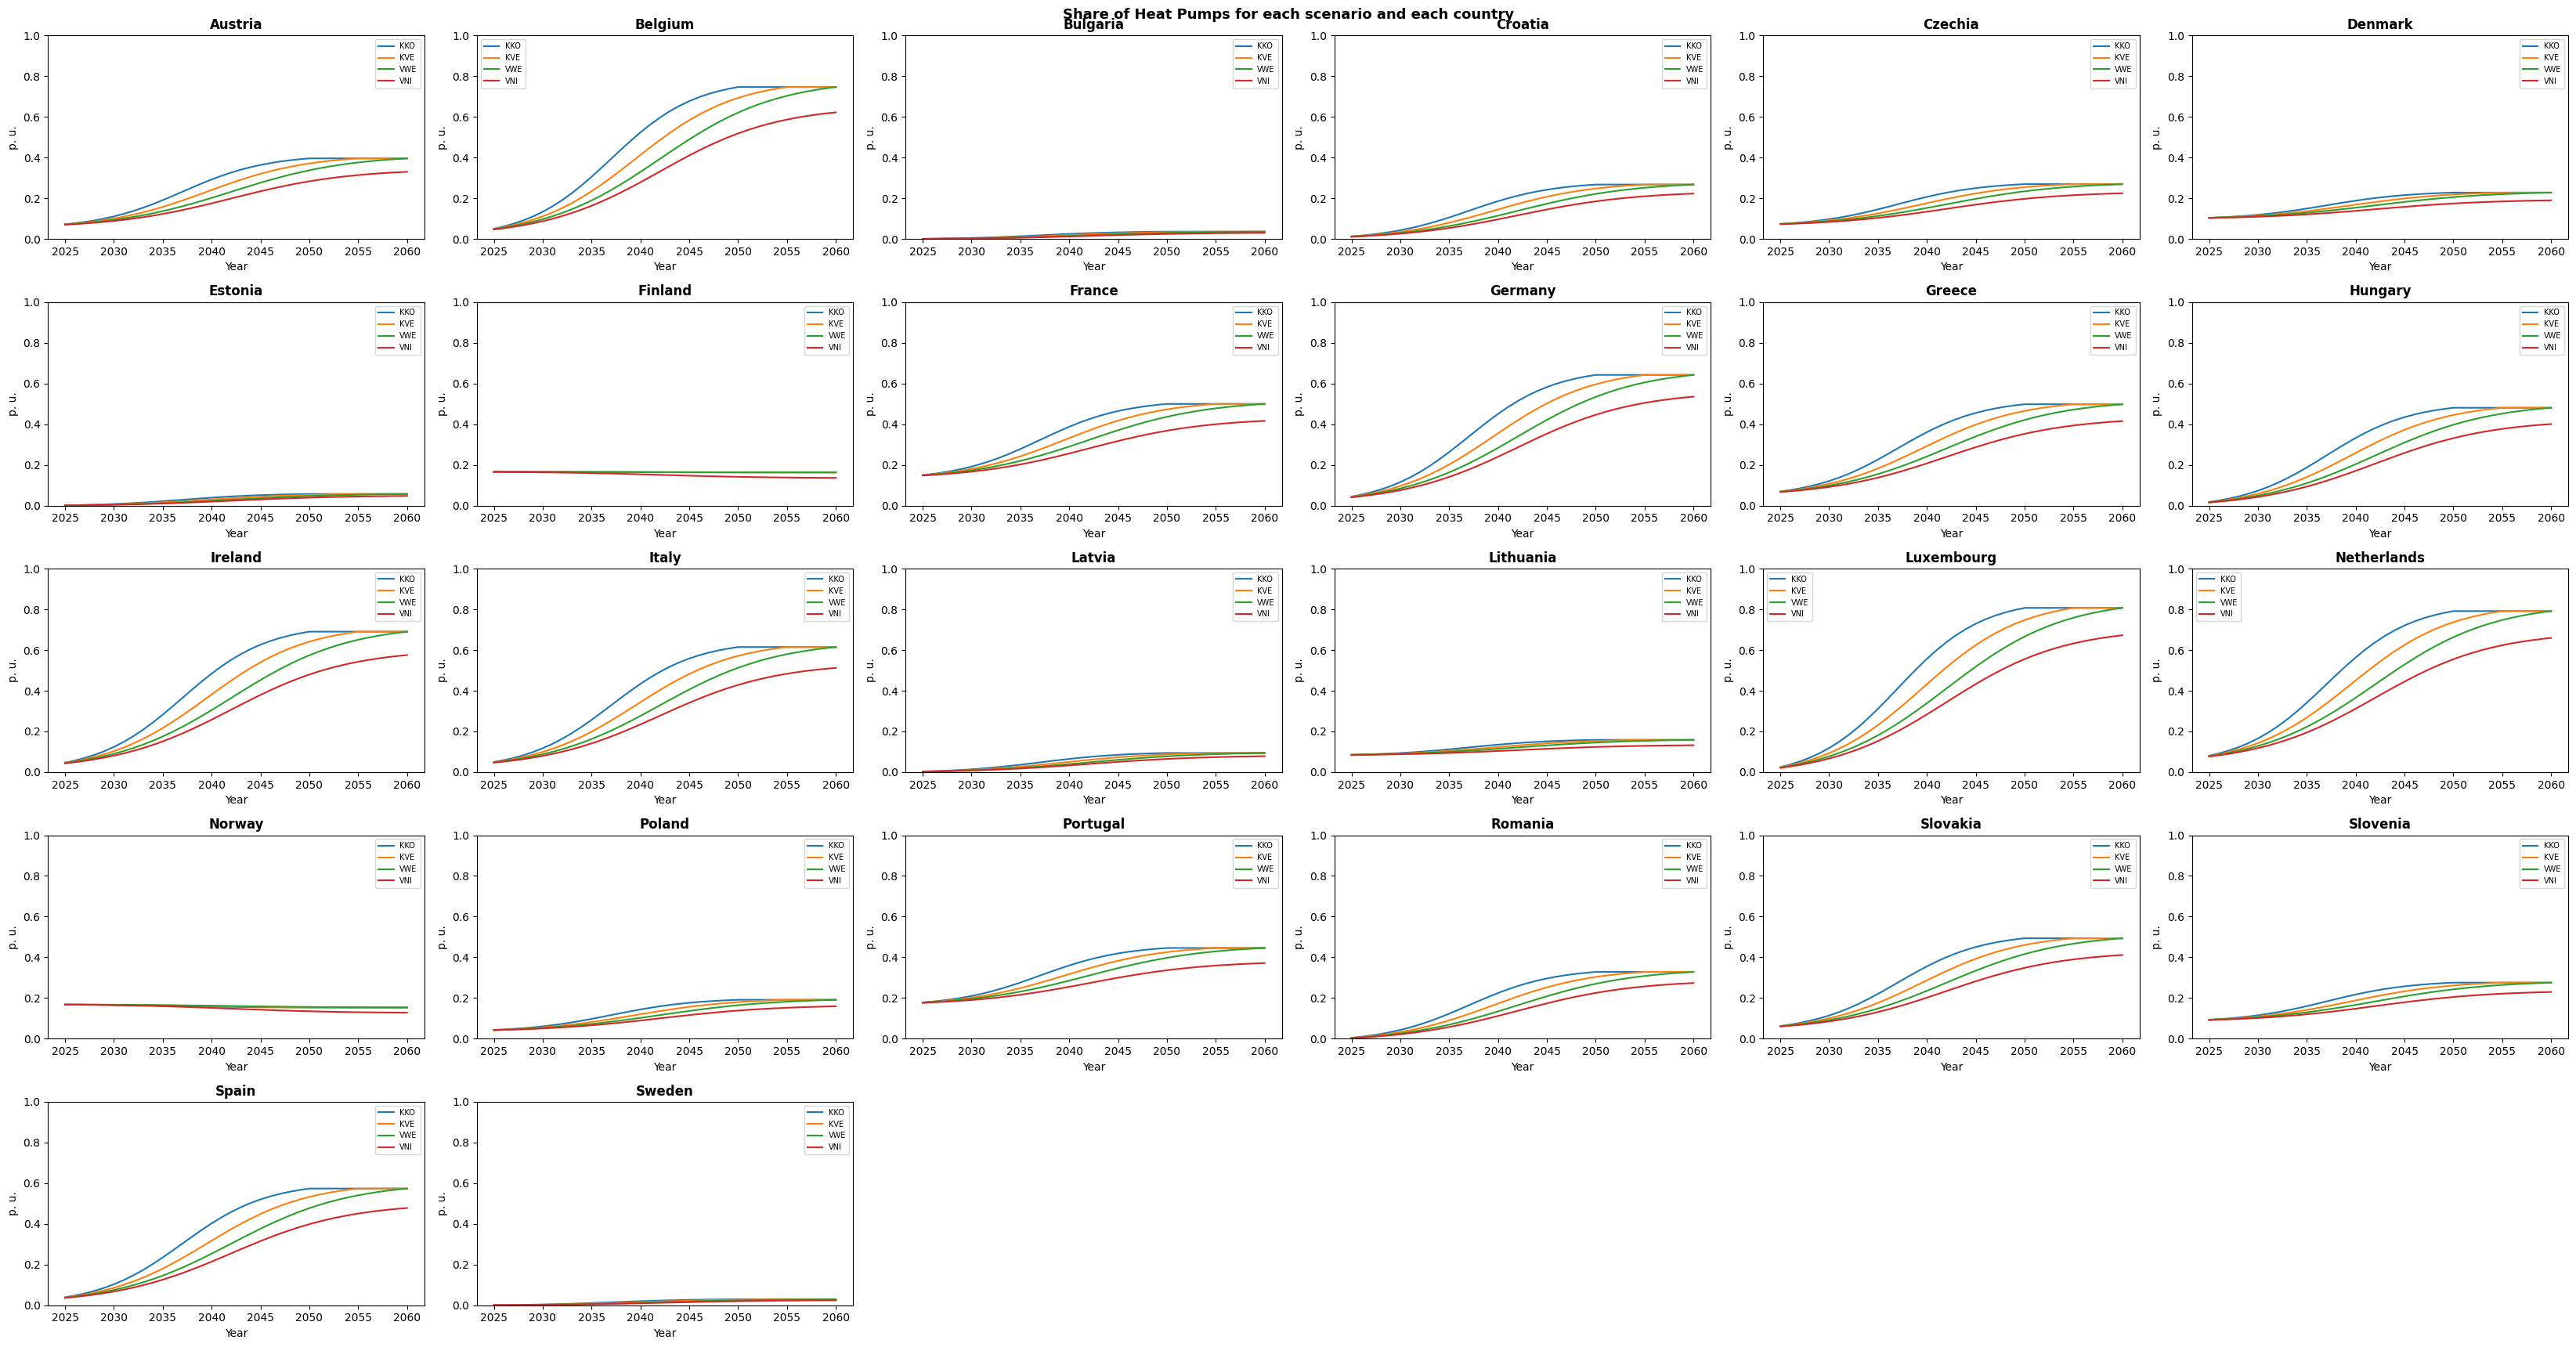

In [33]:
import matplotlib.pyplot as plt
import math

PROJECTION = hp_shares_proj # or hp_shares_proj_linear or hp_shares_proj

ALL_COUNTRIES = sorted(ALL_COUNTRIES)

n_cols = 6
n_rows = math.ceil(len(ALL_COUNTRIES) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5.5, n_rows * 3.5))
axes = axes.flatten()

for ax, country in zip(axes, ALL_COUNTRIES):
    for scenario in SCENARIOS:
        d = PROJECTION[
            (PROJECTION["country"]  == country) &
            (PROJECTION["scenario"] == scenario)
        ]
        ax.plot(d["year"], d["share_pu"], label=scenario)

    ax.set_title(country, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("p. u.")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1.0)

# hide unused subplots
for ax in axes[len(ALL_COUNTRIES):]:
    ax.set_visible(False)

plt.suptitle("Share of Heat Pumps for each scenario and each country",
             fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("Results/HP_electricity_demand_2025_2060.png", dpi=300)
plt.show()

# Calculation of HP Electricity Demand

In [34]:
proj

,,gdp_growth_rate_Percent,ln_hdd,ln_total_floor,ln_thermal_index,total_floor_m2,thermal_index,panel_predictions
country,year,,,,,,,
Austria,2025,-0.036296,8.125675,19.995536,5.198034,4.830042e+08,179.916287,226387.416773
Belgium,2025,1.156512,7.648291,20.371332,5.275816,7.033269e+08,194.550003,261095.791332
Bulgaria,2025,2.927476,7.767877,19.637591,5.101480,3.376737e+08,163.264914,61972.950714
Croatia,2025,3.896182,7.495500,19.089725,4.982001,1.952370e+08,144.765772,74053.995229
Czechia,2025,2.120203,7.954813,19.817235,5.083922,4.041249e+08,160.405820,230494.065402
...,...,...,...,...,...,...,...,...
Romania,2060,1.007720,7.841816,19.911950,4.905085,4.442729e+08,133.974425,152163.047245
Slovakia,2060,0.888031,7.957286,18.989165,4.969689,1.765588e+08,142.982070,48730.205554
Slovenia,2060,1.617258,7.715048,18.103974,4.929964,7.285442e+07,137.374525,24172.921041


## COP Calculation

In [35]:
# COP mode: dynamic formula is COP = COP_base[country] * (THERMAL_REF / thermal_index) ^ COP_ALPHA
# poorly insulated building -> high thermal_index -> high supply temp -> low COP (and
# the other way round for a well insulated one). Parameters come from scenario_config.py.
from scenario_config import (
    USE_DYNAMIC_COP,
    COP_ALPHA,
    THERMAL_REF,
    COP_MAX,
    COP_MAP,
)

cop_df = floor_panel[["thermal_index"]].copy().reset_index()
cop_df["COP_base"] = cop_df["country"].map(COP_MAP)   # climate-zone anchor, preserved in both modes

if USE_DYNAMIC_COP:
    # COP_ALPHA is the exponent here - shifts all countries proportionally while
    # keeping their COP_base differences
    cop_df["COP"] = (
        cop_df["COP_base"] * (THERMAL_REF / cop_df["thermal_index"]) ** COP_ALPHA
    ).clip(upper=COP_MAX)
else:
    cop_df["COP"] = cop_df["COP_base"]   # identical to old constant behavior

cop_df = cop_df.set_index(["country", "year"])

# preview
cop_df.loc[
    cop_df.index.get_level_values("country").isin(["Germany", "Sweden", "Spain"]) &
    cop_df.index.get_level_values("year").isin([2020, 2030, 2040, 2050, 2060])
][["thermal_index", "COP_base", "COP"]]

thermal_index  COP_base       COP
country year                                   
Germany 2020     183.562510       4.0  3.764889
Spain   2020     151.823504       4.3  4.284441
Sweden  2020     158.443972       3.3  3.246225
Germany 2030     169.963246       4.0  3.852839
        2040     163.367067       4.0  3.898863
        2050     156.765311       4.0  3.947411
        2060     151.402714       4.0  3.988846
Spain   2030     130.997161       4.3  4.478342
        2040     120.996733       4.3  4.586314
        2050     113.912511       4.3  4.670081
        2060     108.131793       4.3  4.743619
Sweden  2030     138.612691       3.3  3.379095
        2040     126.907634       3.3  3.469725
        2050     117.159686       3.3  3.553922
        2060     109.629646       3.3  3.625458

In [36]:
PROJ_YEARS = [2025, 
              2026, 2027, 2028, 2029, 
              2030, 2035, 2040, 2045, 2050, 2055, 2060]

# COP by country group (from Rivière et al. 2009)
#Southern Europe  & ES, PT, IT, GR, HR, SI & 4.3 
#Western/Central  & FR, DE, AT, BE, NL, LU, IE & 4.0
#Eastern Europe   & PL, CZ, SK, HU, RO, BG & 3.5 
#Nordic/Baltic    & SE, FI, NO, DK, EE, LV, LT & 3.3 

# service sector multiplier (HP demand in services on top of residential)
# tunable via scenario_config.py
from scenario_config import SERVICE_MULTIPLIER

# merge projection shares with total heat demand from ML model
# --> if USE_HDD_CDD_SCENARIOS, each HP-adoption scenario (KKO/KVE/VWE/VNI) is paired with its
#     matching climate-scenario total-heat-demand path (SSP1/SSP2/SSP5/SSP3); otherwise every
#     HP-adoption scenario reuses the single RCP4.5-based total-heat-demand path (previous behavior).
if USE_HDD_CDD_SCENARIOS:
    proj_heat = proj_scenarios.reset_index()[["country", "year", "scenario", "panel_predictions"]].copy()
    merge_keys = ["country", "year", "scenario"]
else:
    proj = proj.reset_index()
    proj_heat = proj[["country", "year", "panel_predictions"]].copy()
    merge_keys = ["country", "year"]

hp_demand_proj = hp_shares_proj.merge(proj_heat,
                                       on=merge_keys,
                                       how="left")

#hp_demand_proj["COP"] = hp_demand_proj["country"].map(COP_MAP)
hp_demand_proj = hp_demand_proj.merge(
    cop_df[["COP"]].reset_index(), on=["country", "year"], how="left"
)

# formula: Demand_HP (TWh) = Heat(TJ) * (1/3600) * share_HP / (COP-1) * 1.25
hp_demand_proj["Demand_HP_TWh"] = (
    hp_demand_proj["panel_predictions"]
    * (1 / 3600)
    * hp_demand_proj["share_pu"]
    #/ (hp_demand_proj["COP"] - 1)
    / (hp_demand_proj["COP"])
    * SERVICE_MULTIPLIER
)

#print(hp_demand_proj.head(20).to_string())
#print(f"\nShape: {hp_demand_proj.shape}")
hp_demand_proj = hp_demand_proj[hp_demand_proj.year.isin(PROJ_YEARS)]
hp_demand_proj = hp_demand_proj.reset_index(drop=True)
hp_demand_proj[hp_demand_proj.country=="Germany"]

,country,year,scenario,share_pu,panel_predictions,COP,Demand_HP_TWh
108,Germany,2025,KKO,0.043720,1.849723e+06,3.792693,5.922983
109,Germany,2026,KKO,0.053225,1.812143e+06,3.803380,7.044321
110,Germany,2027,KKO,0.064797,1.761846e+06,3.814074,8.314426
111,Germany,2028,KKO,0.078772,1.723021e+06,3.825767,9.854715
112,Germany,2029,KKO,0.095488,1.653586e+06,3.838625,11.426112
113,Germany,2030,KKO,0.115252,1.628896e+06,3.852839,13.535001
114,Germany,2035,KKO,0.263078,1.550001e+06,3.872923,29.246581
115,Germany,2040,KKO,0.450462,1.491304e+06,3.898863,47.861268
116,Germany,2045,KKO,0.582497,1.447887e+06,3.924411,59.696853
117,Germany,2050,KKO,0.642021,1.366143e+06,3.947411,61.720689


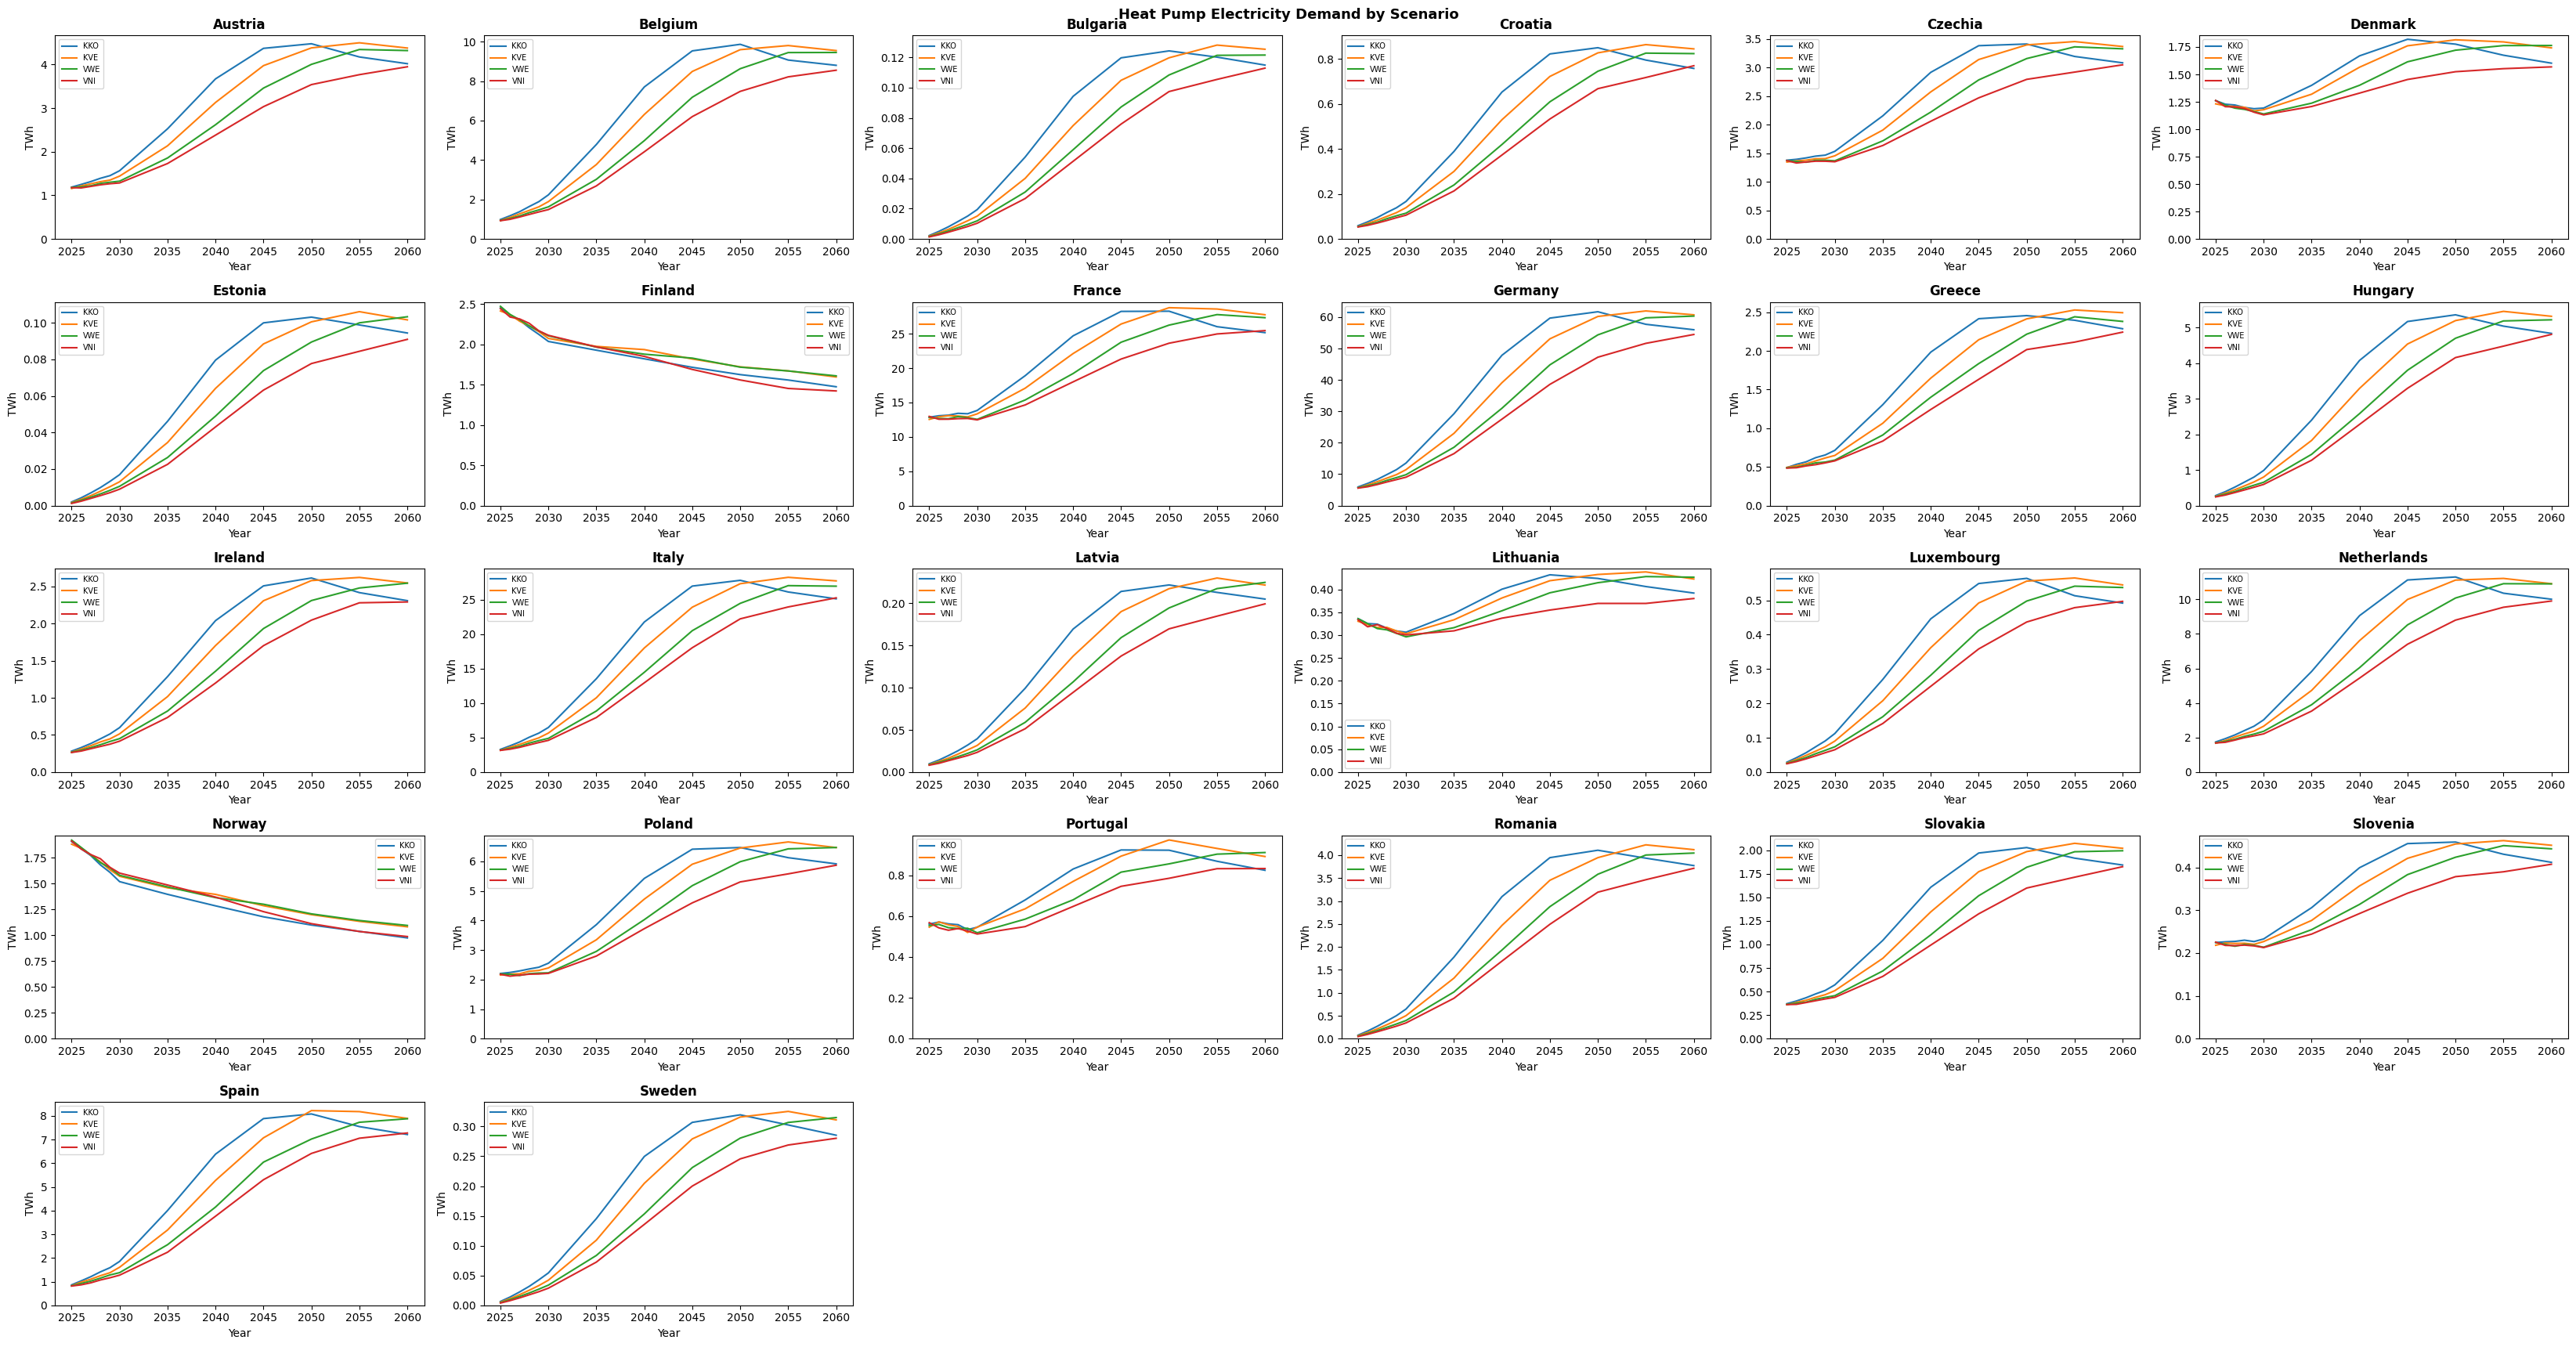

In [37]:
import matplotlib.pyplot as plt
import math

CHECK_COUNTRIES = ALL_COUNTRIES   # or any list of countries
#CHECK_COUNTRIES = ["Bulgaria"]

CHECK_COUNTRIES = sorted(CHECK_COUNTRIES)

n_cols = 6
n_rows = math.ceil(len(CHECK_COUNTRIES) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5.5, n_rows * 3.5))
axes = axes.flatten()

for ax, country in zip(axes, CHECK_COUNTRIES):
    for scenario in SCENARIOS:
        d = hp_demand_proj[
            (hp_demand_proj["country"]  == country) &
            (hp_demand_proj["scenario"] == scenario)
        ]
        ax.plot(d["year"], d["Demand_HP_TWh"], label=scenario)

    ax.set_title(country, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("TWh")
    ax.legend(fontsize=7)
    ax.set_ylim(0, )

# hide unused subplots
for ax in axes[len(CHECK_COUNTRIES):]:
    ax.set_visible(False)

plt.suptitle("Heat Pump Electricity Demand by Scenario",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Results/HP_electricity_demand_2025_2060.png", dpi=300)
plt.show()


In [38]:
hp_demand_proj.to_csv("Results/hp_demand_proj.csv")
hp_demand_proj[hp_demand_proj["country"] == "Germany"]

,country,year,scenario,share_pu,panel_predictions,COP,Demand_HP_TWh
108,Germany,2025,KKO,0.043720,1.849723e+06,3.792693,5.922983
109,Germany,2026,KKO,0.053225,1.812143e+06,3.803380,7.044321
110,Germany,2027,KKO,0.064797,1.761846e+06,3.814074,8.314426
111,Germany,2028,KKO,0.078772,1.723021e+06,3.825767,9.854715
112,Germany,2029,KKO,0.095488,1.653586e+06,3.838625,11.426112
113,Germany,2030,KKO,0.115252,1.628896e+06,3.852839,13.535001
114,Germany,2035,KKO,0.263078,1.550001e+06,3.872923,29.246581
115,Germany,2040,KKO,0.450462,1.491304e+06,3.898863,47.861268
116,Germany,2045,KKO,0.582497,1.447887e+06,3.924411,59.696853
117,Germany,2050,KKO,0.642021,1.366143e+06,3.947411,61.720689
